In [1]:
!pip install dtreeviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.3/102.3 kB 1.2 MB/s eta 0:00:00


In [2]:
import pandas as pd

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import PowerTransformer
import seaborn as sns
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, validation_curve, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error,
                             confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,
                             roc_curve, roc_auc_score, ConfusionMatrixDisplay, precision_recall_curve)
import statsmodels.api as sm
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import Ridge, Lasso
from sklearn.feature_selection import RFE, RFECV
from sklearn.tree import DecisionTreeClassifier
from dtreeviz import model
from sklearn.ensemble import VotingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_validate

In [5]:
#Lectura dataset
df_frisa = pd.read_csv('/content/drive/MyDrive/TEC/Semestre 4/Análisis de ciencia de datos/Reto_Frisa/Entrega_1/Grupo201_Santa Catarina Base de Datos 6 meses Rev 1.csv')

In [6]:
# Se elimina la coma y se convierten a float
cols_coma = ['DE Forja Real 1', 'DE Forja Real 2',
             'DI Forja Real 1', 'DI Forja Real 2',
             'Peso Calculado', 'Peso de Forja Configurado',
             'DE Final', 'DI Final']

for col in cols_coma:
    df_frisa[col] = df_frisa[col].str.replace(',', '').astype(float)

In [7]:
pd.set_option('display.max_columns', None)
df_frisa

,Orden,N Cliente,Industria,Tipo,Material,Familia,Roladora,DE Final,DI Final,Altura Final,Exceso DE configurado,Exceso DI Configurado,Exceso Configurado Altura,DE Forja Configurada,DI Forja Configurada,Altura Forja Configurada,Peso de Forja Configurado,DE Forja Real 1,DE Forja Real 2,DI Forja Real 1,DI Forja Real 2,Altura Forja Real 1,Altura Forja Real 2,Ovalamiento,Pandeamiento,Conicidad 1,Conicidad 2,DE Exceso Real 1,DE Exceso Real 2,DI Exceso Real 1,DI Exceso Real 2,Altura Exceso Real 1,Altura Exceso Real 2,Peso Calculado,% Pesos,Relacion E/A Finales,Familia geométrica,Rango peso,Rango DE,Calidad,Motivo,Planta
0,830720.0,357.0,Oil & Gas,ATR,4130,Aceros,R1,425.0,231.0,80.0,20.0,20.0,22.0,445.0,211.0,102.0,97.0,451.0,451.0,216.0,216.0,98.0,98.0,0.0,0.0,0.0,0.0,26.0,26.0,15.0,15.0,18.0,18.0,94.0,-3.18,0.95,Cuadrado 3,De 0 a 100kg,De 250 a 500mm,Reproceso,Altura Corta / Critica,Santa Catarina
1,826498.0,302.0,Oil & Gas,AR,105,Aceros,R3,1810.0,1607.0,71.0,19.0,19.0,20.0,1829.0,1588.0,91.0,465.0,1841.0,1841.0,1589.0,1589.0,86.0,86.0,0.0,0.0,0.0,0.0,31.0,31.0,18.0,18.0,15.0,15.0,458.0,-1.50,1.11,Cuadrado 1,De 250 a 500kg,De 1500 a 2000mm,Rechazo,Altura Corta / Critica,Santa Catarina
2,834913.0,121.0,Oil & Gas,AR,LF6,Aceros,R1,368.0,314.0,52.0,16.0,16.0,29.0,384.0,298.0,81.0,30.0,385.0,385.0,295.0,295.0,76.0,76.0,0.0,0.0,0.0,0.0,17.0,17.0,19.0,19.0,24.0,24.0,29.0,-4.70,0.34,Cuadrado 3,De 0 a 100kg,De 250 a 500mm,Reproceso,Arroyo,Santa Catarina
3,834913.0,121.0,Oil & Gas,AR,LF6,Aceros,R1,368.0,314.0,52.0,16.0,16.0,29.0,384.0,298.0,81.0,30.0,393.0,393.0,305.0,305.0,76.0,76.0,0.0,0.0,0.0,0.0,25.0,25.0,9.0,9.0,24.0,24.0,29.0,-4.33,0.34,Cuadrado 3,De 0 a 100kg,De 250 a 500mm,Reproceso,Arroyo,Santa Catarina
4,837146.0,349.0,Oil & Gas,ARD,4340 BS,Aceros,R1,540.0,369.0,435.0,24.0,24.0,26.0,564.0,345.0,461.0,566.0,565.0,565.0,349.0,349.0,461.0,461.0,0.0,0.0,0.0,0.0,25.0,25.0,20.0,20.0,26.0,26.0,560.0,-1.08,0.19,Casquillo 4,De 500 a 750kg,De 500 a 750mm,Reproceso,Cascaras / Pozos Exterior,Santa Catarina
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7239,823142.0,89.0,Heavy Industries,AR,42CrMo4,Aceros,R3,1476.0,1252.0,89.0,16.0,16.0,17.0,1492.0,1236.0,106.0,455.0,1496.0,1496.0,1237.0,1237.0,104.0,104.0,0.0,0.0,0.0,0.0,20.0,20.0,15.0,15.0,15.0,15.0,455.0,0.10,1.06,Cuadrado 1,De 250 a 500kg,De 1250 a 1500mm,Reproceso,Traslape Cara Superior,Santa Catarina
7240,822048.0,9.0,Oil & Gas,ATR,316L,Aceros,R1,375.0,213.0,292.0,23.0,29.0,25.0,398.0,184.0,317.0,246.0,391.0,391.0,168.0,168.0,316.0,316.0,0.0,0.0,0.0,0.0,16.0,16.0,45.0,45.0,24.0,24.0,243.0,-1.11,0.26,Casquillo 1,De 200 a 250kg,De 250 a 500mm,Reproceso,Traslape Exterior,Santa Catarina
7241,834305.0,100.0,Heavy Industries,ARC,105,Aceros,R3,914.0,616.0,306.0,18.0,18.0,18.0,932.0,598.0,324.0,1023.0,935.0,935.0,600.0,600.0,322.0,322.0,0.0,0.0,0.0,0.0,21.0,21.0,16.0,16.0,16.0,16.0,1017.0,-0.57,0.46,Cuadrado 3,De 1000 a 1250kg,De 750 a 1000mm,Rechazo,Traslape Exterior,Santa Catarina
7242,834794.0,467.0,Oil & Gas,AT,304L,Aceros,P3,546.0,254.0,394.0,27.0,44.0,37.0,573.0,210.0,431.0,762.0,560.0,560.0,195.0,195.0,422.0,422.0,0.0,0.0,0.0,0.0,14.0,14.0,59.0,59.0,28.0,28.0,724.0,-5.02,0.34,Cuadrado 3,De 750 a 1000kg,De 500 a 750mm,Reproceso,Traslape Interior,Santa Catarina


# Selección del modelo

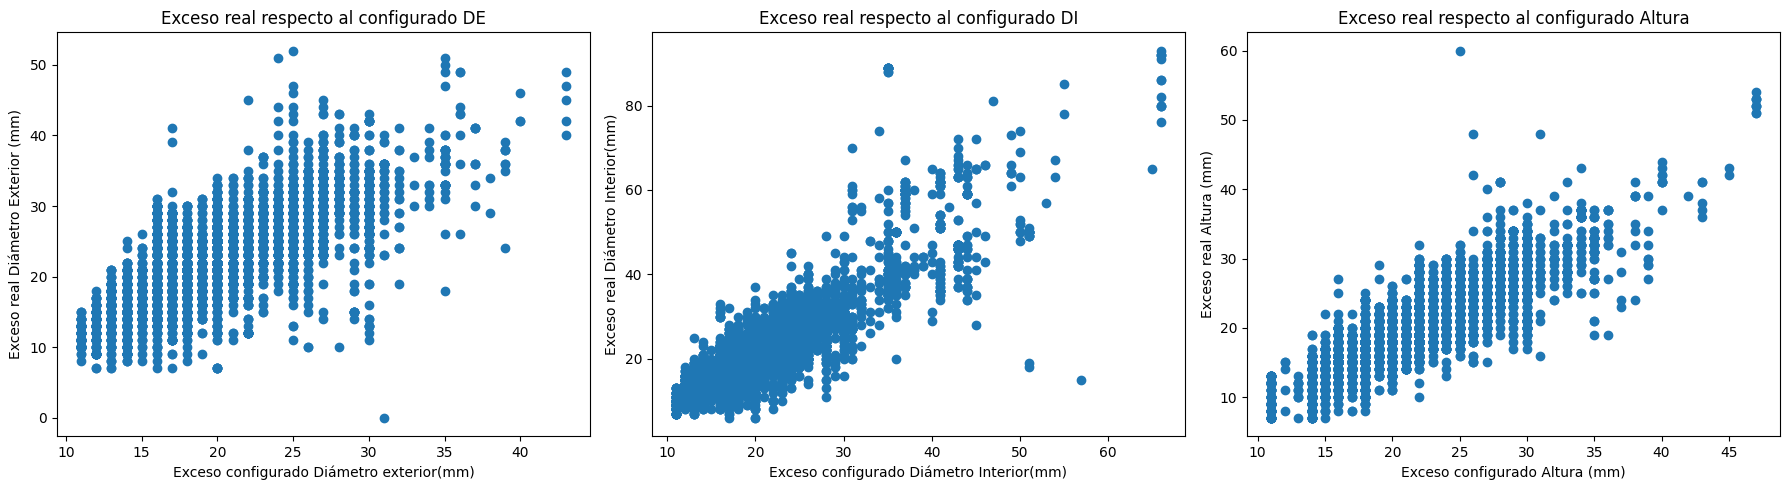

In [8]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
ax1.scatter(df_frisa['Exceso DE configurado'],df_frisa['DE Exceso Real 1'])
ax1.set_title("Exceso real respecto al configurado DE")
ax1.set_xlabel("Exceso configurado Diámetro exterior(mm)")
ax1.set_ylabel("Exceso real Diámetro Exterior (mm)")
ax2.scatter(df_frisa['Exceso DI Configurado'],df_frisa['DI Exceso Real 1'])
ax2.set_title("Exceso real respecto al configurado DI")
ax2.set_xlabel("Exceso configurado Diámetro Interior(mm)")
ax2.set_ylabel("Exceso real Diámetro Interior(mm)")
ax3.scatter(df_frisa['Exceso Configurado Altura'],df_frisa['Altura Exceso Real 1'])
ax3.set_title("Exceso real respecto al configurado Altura")
ax3.set_xlabel("Exceso configurado Altura (mm)")
ax3.set_ylabel("Exceso real Altura (mm)")

plt.tight_layout()
plt.show()

In [9]:
df_modelo = df_frisa.copy()
df_modelo['Exceso volumétrico configurado'] = (1/1000)*(((df_modelo['Exceso DE configurado']+df_modelo['DE Final'])**2-(df_modelo['DE Final'])**2)*np.pi*df_modelo['Altura Final'] +
                                                        ((df_modelo['Exceso DE configurado']+df_modelo['DE Final'])**2-(df_modelo['DI Final']-df_modelo['Exceso DI Configurado'])**2)*np.pi*df_modelo['Exceso Configurado Altura'] +
                                                        ((df_modelo['DI Final'])**2-(df_modelo['DI Final']-df_modelo['Exceso DI Configurado'])**2)*np.pi*df_modelo['Altura Final'])
df_modelo['Exceso volumétrico Real'] = (1/1000)*(((df_modelo['DE Exceso Real 1']+df_modelo['DE Forja Real 1'])**2-(df_modelo['DE Forja Real 1'])**2)*np.pi*df_modelo['Altura Forja Real 1'] +
                                                 ((df_modelo['DE Exceso Real 1']+df_modelo['DE Forja Real 1'])**2-(df_modelo['DI Forja Real 1']-df_modelo['DI Exceso Real 1'])**2)*np.pi*df_modelo['Altura Exceso Real 1'] +
                                                 ((df_modelo['DI Forja Real 1'])**2-(df_modelo['DI Forja Real 1']-df_modelo['DI Exceso Real 1'])**2)*np.pi*df_modelo['Altura Forja Real 1'])

#Tras inspeccionar, se notó que la última fila de la tabla contiene únicamente valores nulos.
#Se descarta, pues no aporta información alguna
df_modelo = df_modelo.dropna(how='all').copy()



In [10]:
df_modelo.to_csv('df_modelo.csv')

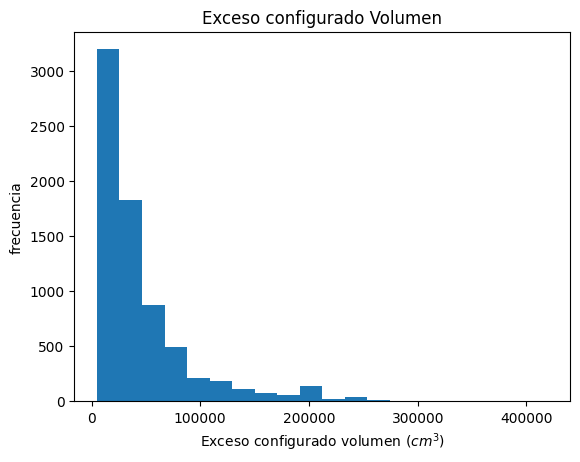

In [11]:
plt.hist(df_modelo['Exceso volumétrico configurado'],bins = 20)
plt.title("Exceso configurado Volumen")
plt.xlabel("Exceso configurado volumen ($cm^3$)")
plt.ylabel("frecuencia")
plt.show()

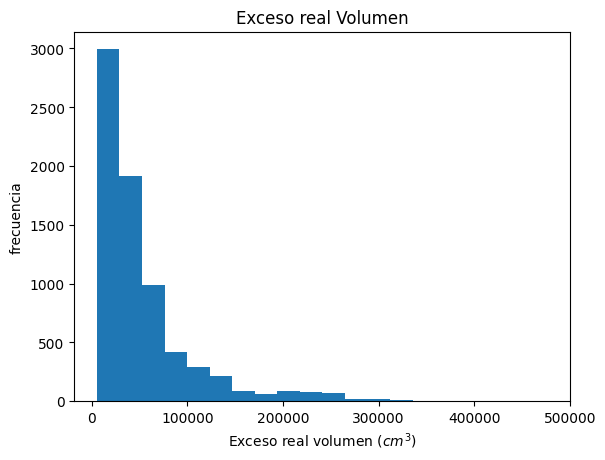

In [12]:
plt.hist(df_modelo['Exceso volumétrico Real'], bins = 20)
plt.title("Exceso real Volumen")
plt.xlabel("Exceso real volumen ($cm^3$)")
plt.ylabel("frecuencia")
plt.show()

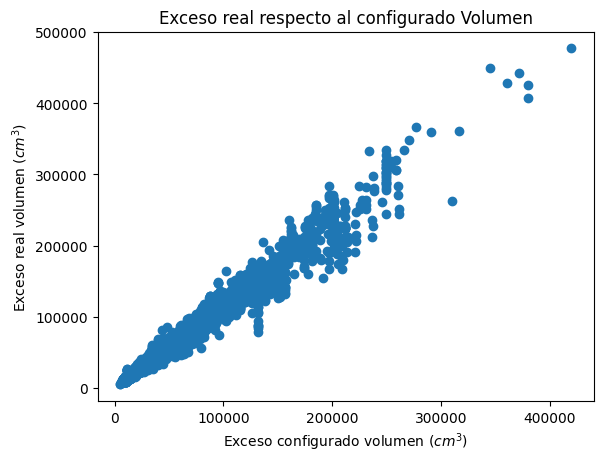

In [13]:

plt.scatter(df_modelo['Exceso volumétrico configurado'],df_modelo['Exceso volumétrico Real'])
plt.title("Exceso real respecto al configurado Volumen")
plt.xlabel("Exceso configurado volumen ($cm^3$)")
plt.ylabel("Exceso real volumen ($cm^3$)")
plt.show()


Se observa una distribución de los datos que sugiere poder usarse como predictor para una regresión lineal múltiple.
Se sospecha que puede existir heterocedasticidad. Para prevenirla, se aplica transformación Box Cox para estabilizar la varianza.

La transformación aplica $y = \frac{x^\lambda-1}{\lambda} $ buscando el lambda óptimo para normalizar los datos.

In [14]:
# Hacemos transformación

boxcox_X = PowerTransformer(method='box-cox')
boxcox_y = PowerTransformer(method='box-cox')

exceso_volumen_config = df_modelo['Exceso volumétrico configurado']

# Reshape the Series to a 2D array as required by fit_transform
exceso_volumen_config_transformado =  boxcox_X.fit_transform(exceso_volumen_config.values.reshape(-1,1))

df_modelo['Exceso volumétrico config transformado'] = exceso_volumen_config_transformado

exceso_volumen_real = df_modelo['Exceso volumétrico Real']

# Reshape the Series to a 2D array and correct the typo in fit_transform
exceso_volumen_real_transformado = boxcox_y.fit_transform(exceso_volumen_real.values.reshape(-1,1))
# Get the lambda value from the fitted transformer
lambda_optimo_x = boxcox_X.lambdas_[0]
lambda_optimo_y = boxcox_y.lambdas_[0]

df_modelo['Exceso volumétrico real transformado'] = exceso_volumen_real_transformado

print("Lambda usado en la transformación de x: ",  lambda_optimo_x)
print("Lambda usado en la transformación de x: ",  lambda_optimo_y)

Lambda usado en la transformación de x:  -0.2526636677064915
Lambda usado en la transformación de x:  -0.2627902794295692


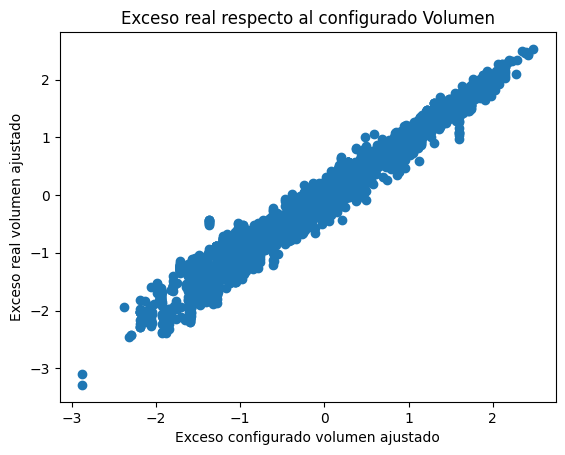

In [15]:
plt.scatter(df_modelo['Exceso volumétrico config transformado'],df_modelo['Exceso volumétrico real transformado'])
plt.title("Exceso real respecto al configurado Volumen")
plt.xlabel("Exceso configurado volumen ajustado")
plt.ylabel("Exceso real volumen ajustado")
plt.show()

Tras la transformación, visualmente se aprecian datos con un comportamiento más normal respecto a su varianza.

In [16]:
df_agrupado = df_modelo.groupby(df_modelo['Familia geométrica'])
df_agrupado['Exceso volumétrico configurado'].describe()

,count,mean,std,min,25%,50%,75%,max
Familia geométrica,,,,,,,,
Arandela 3,227.0,142042.667613,38942.431382,31214.236288,115356.165780,138699.254771,156442.869548,221720.914314
Arandela 4,4.0,156784.951289,4786.656231,149604.966943,156784.951289,159178.279404,159178.279404,159178.279404
Casquillo 1,806.0,49455.608602,54676.744019,8201.165321,18763.727610,22738.847627,69494.291444,270625.430560
Casquillo 10,27.0,90258.916403,65155.707176,30821.285878,50223.209187,55310.000613,112987.786623,260902.081917
Casquillo 4,730.0,37757.474058,30228.019467,8105.007453,24187.580513,37105.313132,41855.344676,371656.844901
Casquillo 6,496.0,48296.701839,39988.542609,14186.599902,30086.577312,44219.418281,47009.077159,380340.408058
Casquillo 8,291.0,63893.519644,51129.020016,18463.592414,40945.545727,43596.465590,53420.122145,419713.599228
Cuadrado 1,931.0,38337.884734,32258.571524,10126.631751,17258.336101,26679.862513,43603.094351,345369.150541
Cuadrado 3,3731.0,40405.262028,41943.077421,5008.352141,13957.012310,22970.492961,57908.631808,360883.544577


In [17]:
df_agrupado['Exceso volumétrico Real'].describe()

,count,mean,std,min,25%,50%,75%,max
Familia geométrica,,,,,,,,
Arandela 3,227.0,146770.805038,39379.043022,32585.896481,125290.907481,136638.360566,160921.893172,252415.590867
Arandela 4,4.0,168274.106696,16031.492469,144392.797695,166648.305794,175025.986996,176651.787898,178651.655096
Casquillo 1,806.0,59019.026952,65748.985085,8273.211466,22249.739350,29071.403062,80985.345159,348052.259162
Casquillo 10,27.0,100622.106590,69677.416410,36936.685005,58778.186956,65474.780723,120149.867032,283650.530250
Casquillo 4,730.0,45027.377073,34583.178604,10927.916948,30357.756449,40965.095858,50054.795473,441843.694163
Casquillo 6,496.0,55854.723397,46384.193205,15985.940811,34164.019002,51370.735594,60127.207262,425055.092137
Casquillo 8,291.0,71176.267839,54946.507224,24780.260816,45302.598587,51596.927123,64309.174451,477147.140546
Cuadrado 1,931.0,46368.196843,39027.618604,9626.785510,22683.239866,32939.071185,56260.530311,449960.005067
Cuadrado 3,3731.0,47807.515248,49837.233679,5373.003084,18449.618610,27206.365168,62189.510471,428394.787340


In [18]:
df_agrupado = df_modelo.groupby(df_modelo['Rango DE'])
df_agrupado['Exceso volumétrico configurado'].describe()

,count,mean,std,min,25%,50%,75%,max
Rango DE,,,,,,,,
De 0 a 250mm,106.0,12207.038448,2898.059223,8105.007453,11345.748771,11345.748771,13476.387119,27093.770487
De 1000 a 1250mm,323.0,98975.618231,69387.220808,25298.862365,45584.408873,72951.683274,158463.262341,316885.011676
De 1250 a 1500mm,668.0,92939.288067,57396.905465,32161.159437,56700.642309,61555.511941,116493.507144,419713.599228
De 1500 a 2000mm,305.0,132361.437806,50623.445713,64947.012007,87063.836855,126856.672547,156442.869548,380340.408058
De 2000 a 2500mm,20.0,200145.788476,73722.965373,119072.870951,154600.144029,174996.204698,253850.136321,360883.544577
De 250 a 500mm,2484.0,21321.354278,12143.659259,5008.352141,13169.223395,17568.401871,24449.570490,83789.464788
De 500 a 750mm,2328.0,34952.503832,24219.584191,10126.631751,16129.941993,29892.585537,44219.418281,195827.923372
De 750 a 1000mm,1009.0,57159.000883,39760.564088,16092.073235,28360.693123,39453.176119,78388.328742,238979.039929


In [19]:
df_agrupado['Exceso volumétrico Real'].describe()

,count,mean,std,min,25%,50%,75%,max
Rango DE,,,,,,,,
De 0 a 250mm,106.0,16841.606770,3870.512418,10927.916948,15165.724376,15879.996882,18227.548850,35499.365525
De 1000 a 1250mm,323.0,117203.629323,84722.881369,28692.171988,51164.893731,81143.646871,190997.875463,366677.514793
De 1250 a 1500mm,668.0,106862.304183,69552.796384,35315.353019,56620.201829,72530.332868,129944.207816,477147.140546
De 1500 a 2000mm,305.0,145172.310388,53256.211893,58135.043249,101632.963361,137984.730938,172068.014150,425055.092137
De 2000 a 2500mm,20.0,247747.757054,91828.919938,140744.708049,185621.454327,221270.692671,316889.271676,449960.005067
De 250 a 500mm,2484.0,25372.336504,12985.513846,5373.003084,16792.457545,21795.449344,30594.239836,105517.866261
De 500 a 750mm,2328.0,41623.520866,27769.530543,9626.785510,21095.342280,34164.019002,53539.706870,224080.379203
De 750 a 1000mm,1009.0,66321.211485,44199.741173,20606.221436,33721.202092,49958.589696,85383.433502,280882.086547


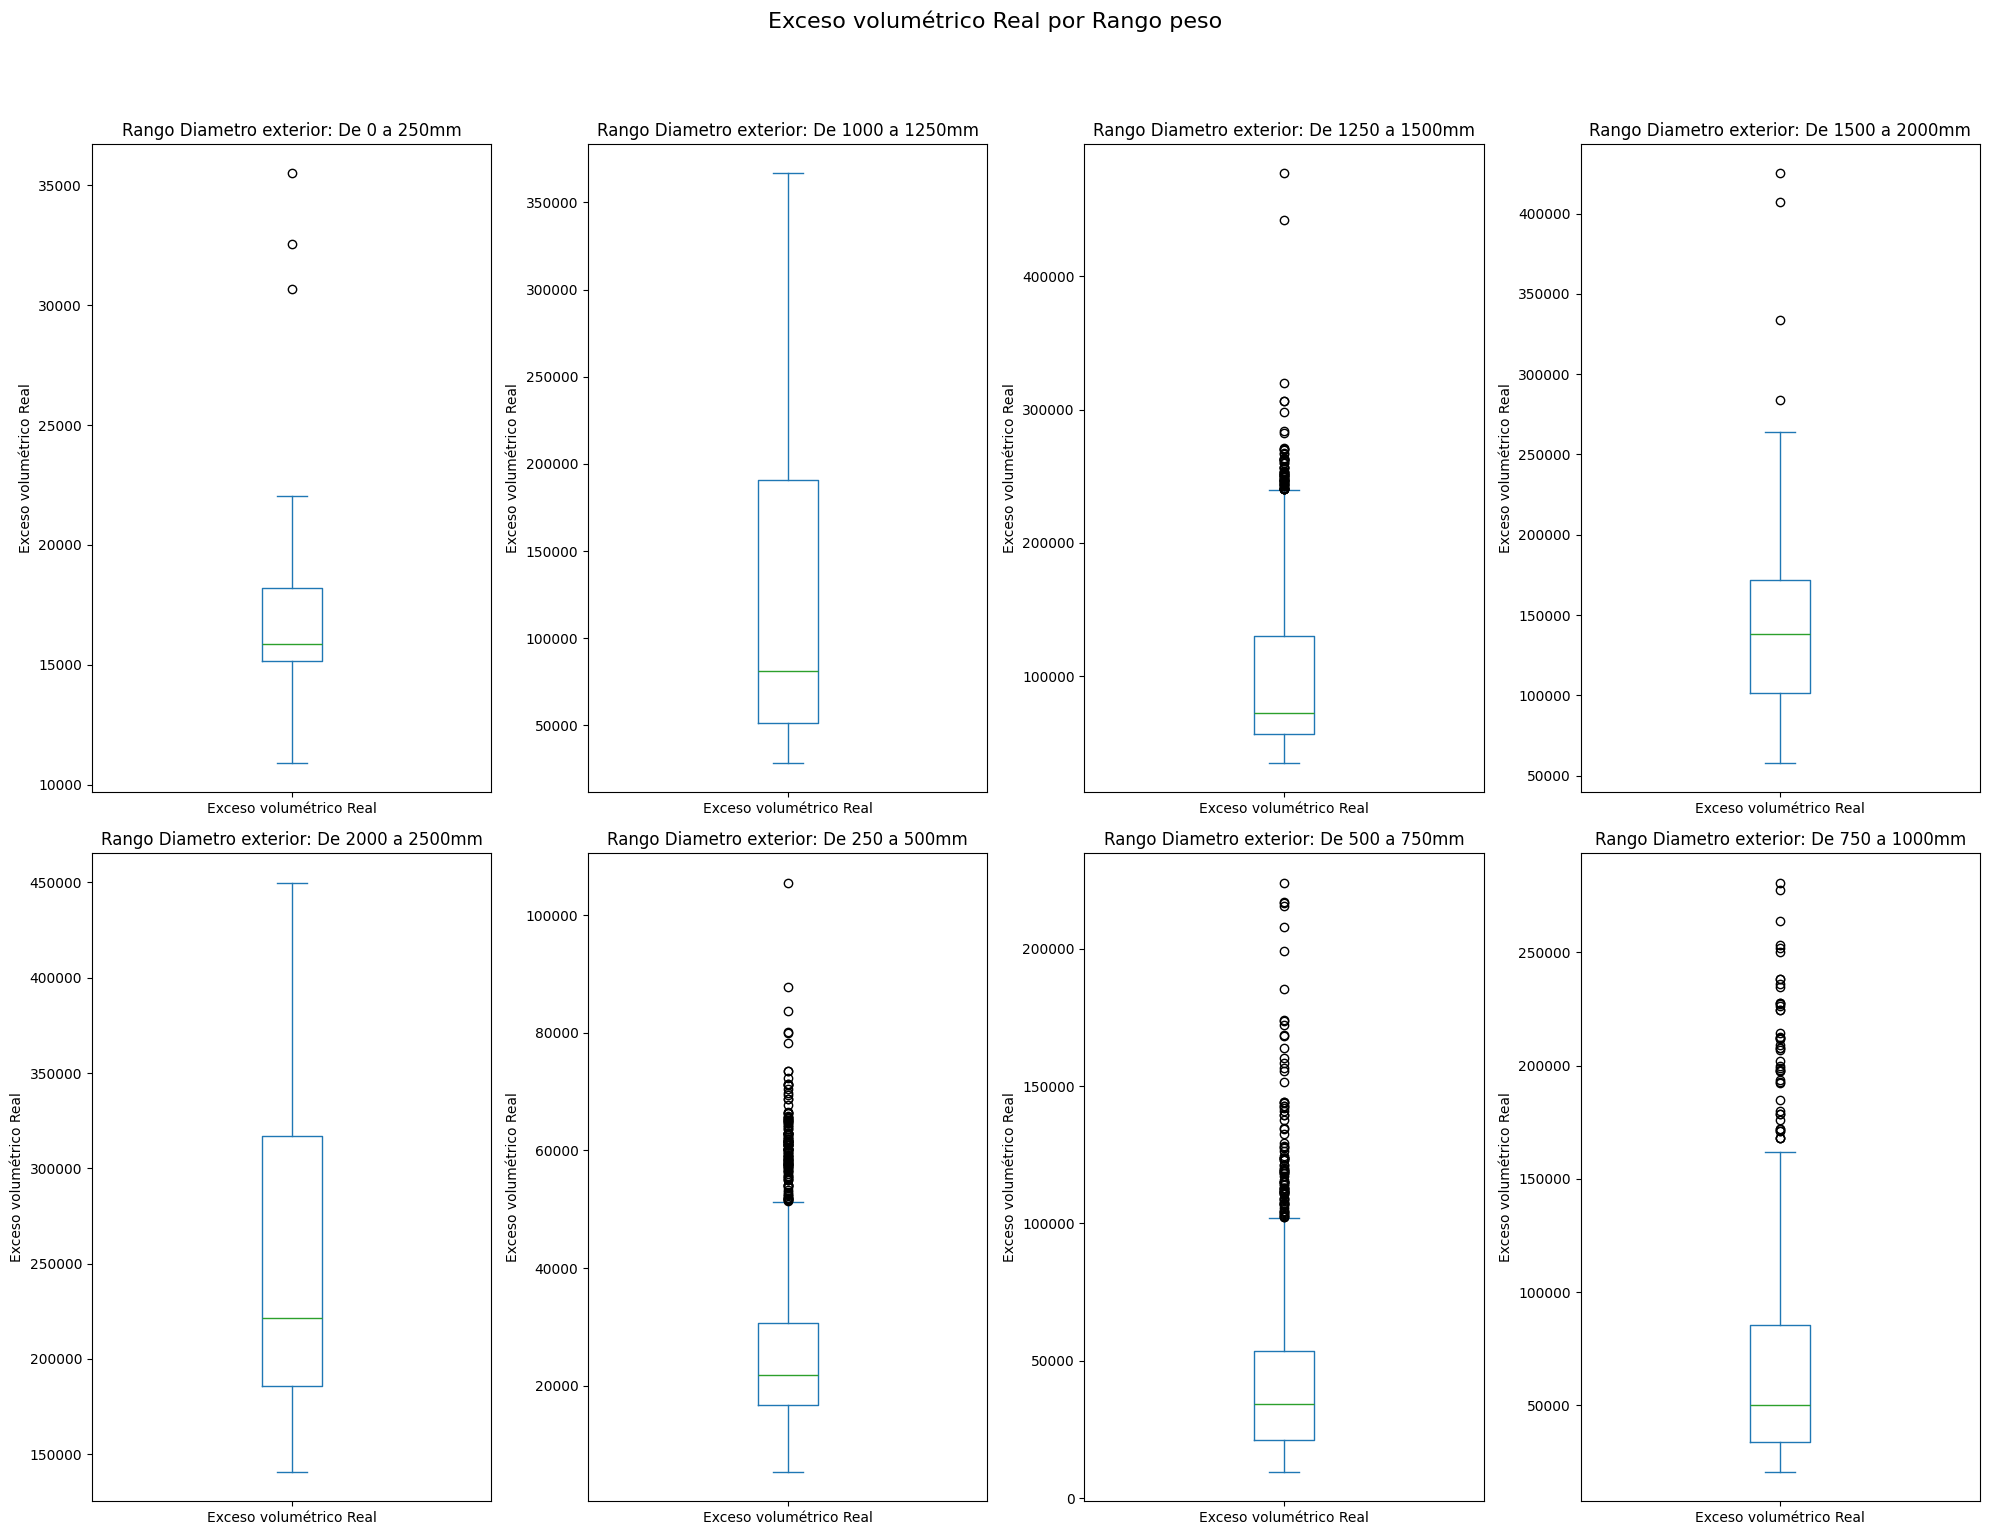

In [20]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 15))
axes = axes.flatten()

for i, (name, group) in enumerate(df_agrupado):
    if i < len(axes):
        group['Exceso volumétrico Real'].plot(kind='box', ax=axes[i], title=f'Rango Diametro exterior: {name}')
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Exceso volumétrico Real')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Exceso volumétrico Real por Rango peso', fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

Se aprecia que el rango en Diámetro exterior puede ser usado como variable predictora por tener mayor media en excesos reales conforme aumenta la magnitud de diámetros.

Se codificara con Label Encoding, pues sí existe una relación jerárquica

In [21]:
rangoDE_Orden = {'De 0 a 250mm': 0, 'De 250 a 500mm': 1, 'De 500 a 750mm':2 ,'De 750 a 1000mm':3, 'De 1000 a 1250mm': 4,
                 'De 1250 a 1500mm': 5,'De 1500 a 2000mm': 6, 'De 2000 a 2500mm': 7 }
df_modelo['Rango DE Codificado'] = df_modelo['Rango DE'].map(rangoDE_Orden)

print("Original 'Rango DE' :", df_modelo['Rango DE'].unique())
print("Encoded 'Rango DE' :", df_modelo['Rango DE Codificado'].unique())

display(df_modelo[['Rango DE', 'Rango DE Codificado']])

Original 'Rango DE' : ['De 250 a 500mm' 'De 1500 a 2000mm' 'De 500 a 750mm' 'De 750 a 1000mm'
 'De 1000 a 1250mm' 'De 1250 a 1500mm' 'De 0 a 250mm' 'De 2000 a 2500mm']
Encoded 'Rango DE' : [1 6 2 3 4 5 0 7]


,Rango DE,Rango DE Codificado
0,De 250 a 500mm,1
1,De 1500 a 2000mm,6
2,De 250 a 500mm,1
3,De 250 a 500mm,1
4,De 500 a 750mm,2
...,...,...
7238,De 1250 a 1500mm,5
7239,De 1250 a 1500mm,5
7240,De 250 a 500mm,1
7241,De 750 a 1000mm,3


In [22]:
df_agrupado = df_modelo.groupby(df_modelo['Rango peso'])
df_agrupado['Exceso volumétrico configurado'].describe()

,count,mean,std,min,25%,50%,75%,max
Rango peso,,,,,,,,
De 0 a 100kg,2661.0,17777.131182,10652.343343,5008.352141,11364.171070,13957.012310,18257.001282,66522.344794
De 100 a 150kg,976.0,24786.296006,8926.064044,11803.868378,19226.170049,21798.883105,28234.222027,64912.467054
De 1000 a 1250kg,261.0,120929.511597,38959.875682,81847.410749,86663.660783,112815.094845,138699.254771,277369.487509
De 1250 a 1500kg,103.0,170551.500579,47967.235103,91353.100429,143938.713463,162099.413935,198946.323217,419713.599228
De 150 a 200kg,690.0,33628.336695,10611.404427,17867.871049,25971.797795,30494.340331,38555.070177,83789.464788
De 1500 a 2000kg,169.0,210962.379420,38357.047846,126345.089316,197169.999187,201209.660083,221720.914314,380340.408058
De 200 a 250kg,623.0,42153.257293,13867.537181,18917.885562,33825.729163,41855.344676,43400.876315,100006.139871
De 2000 a 2500kg,19.0,199336.420647,17214.803575,181557.885911,185269.401171,201381.838210,201381.838210,246162.256974
De 250 a 500kg,1044.0,55004.111575,19629.105104,23720.699003,41608.377794,52946.743823,67148.853767,136798.644623


In [23]:
df_agrupado['Exceso volumétrico Real'].describe()

,count,mean,std,min,25%,50%,75%,max
Rango peso,,,,,,,,
De 0 a 100kg,2661.0,22628.831148,13007.391442,5373.003084,15044.361510,19130.414305,23202.044048,84935.583761
De 100 a 150kg,976.0,30237.554826,12128.716519,10718.133957,22638.368498,26443.665011,33470.513994,90608.005757
De 1000 a 1250kg,261.0,135791.368192,45872.433592,72332.029256,105589.211830,129909.040827,147380.731910,366677.514793
De 1250 a 1500kg,103.0,193566.053279,62099.214824,78947.956349,158518.130256,199312.932943,221169.882105,477147.140546
De 150 a 200kg,690.0,41175.796239,13940.355075,17757.648271,31153.000364,36361.014855,49079.845390,105517.866261
De 1500 a 2000kg,169.0,243842.789821,51008.895352,106140.322580,208811.045101,240430.044186,263875.168965,441843.694163
De 200 a 250kg,623.0,48005.826553,17725.095542,15764.222909,37472.697261,43820.190969,53702.939312,127344.398523
De 2000 a 2500kg,19.0,238808.607039,21827.008422,191956.271709,228377.033373,245488.884863,255294.191375,263767.827027
De 250 a 500kg,1044.0,62539.788288,25663.591162,22356.858234,45127.171268,57093.017807,73524.820516,205690.460277


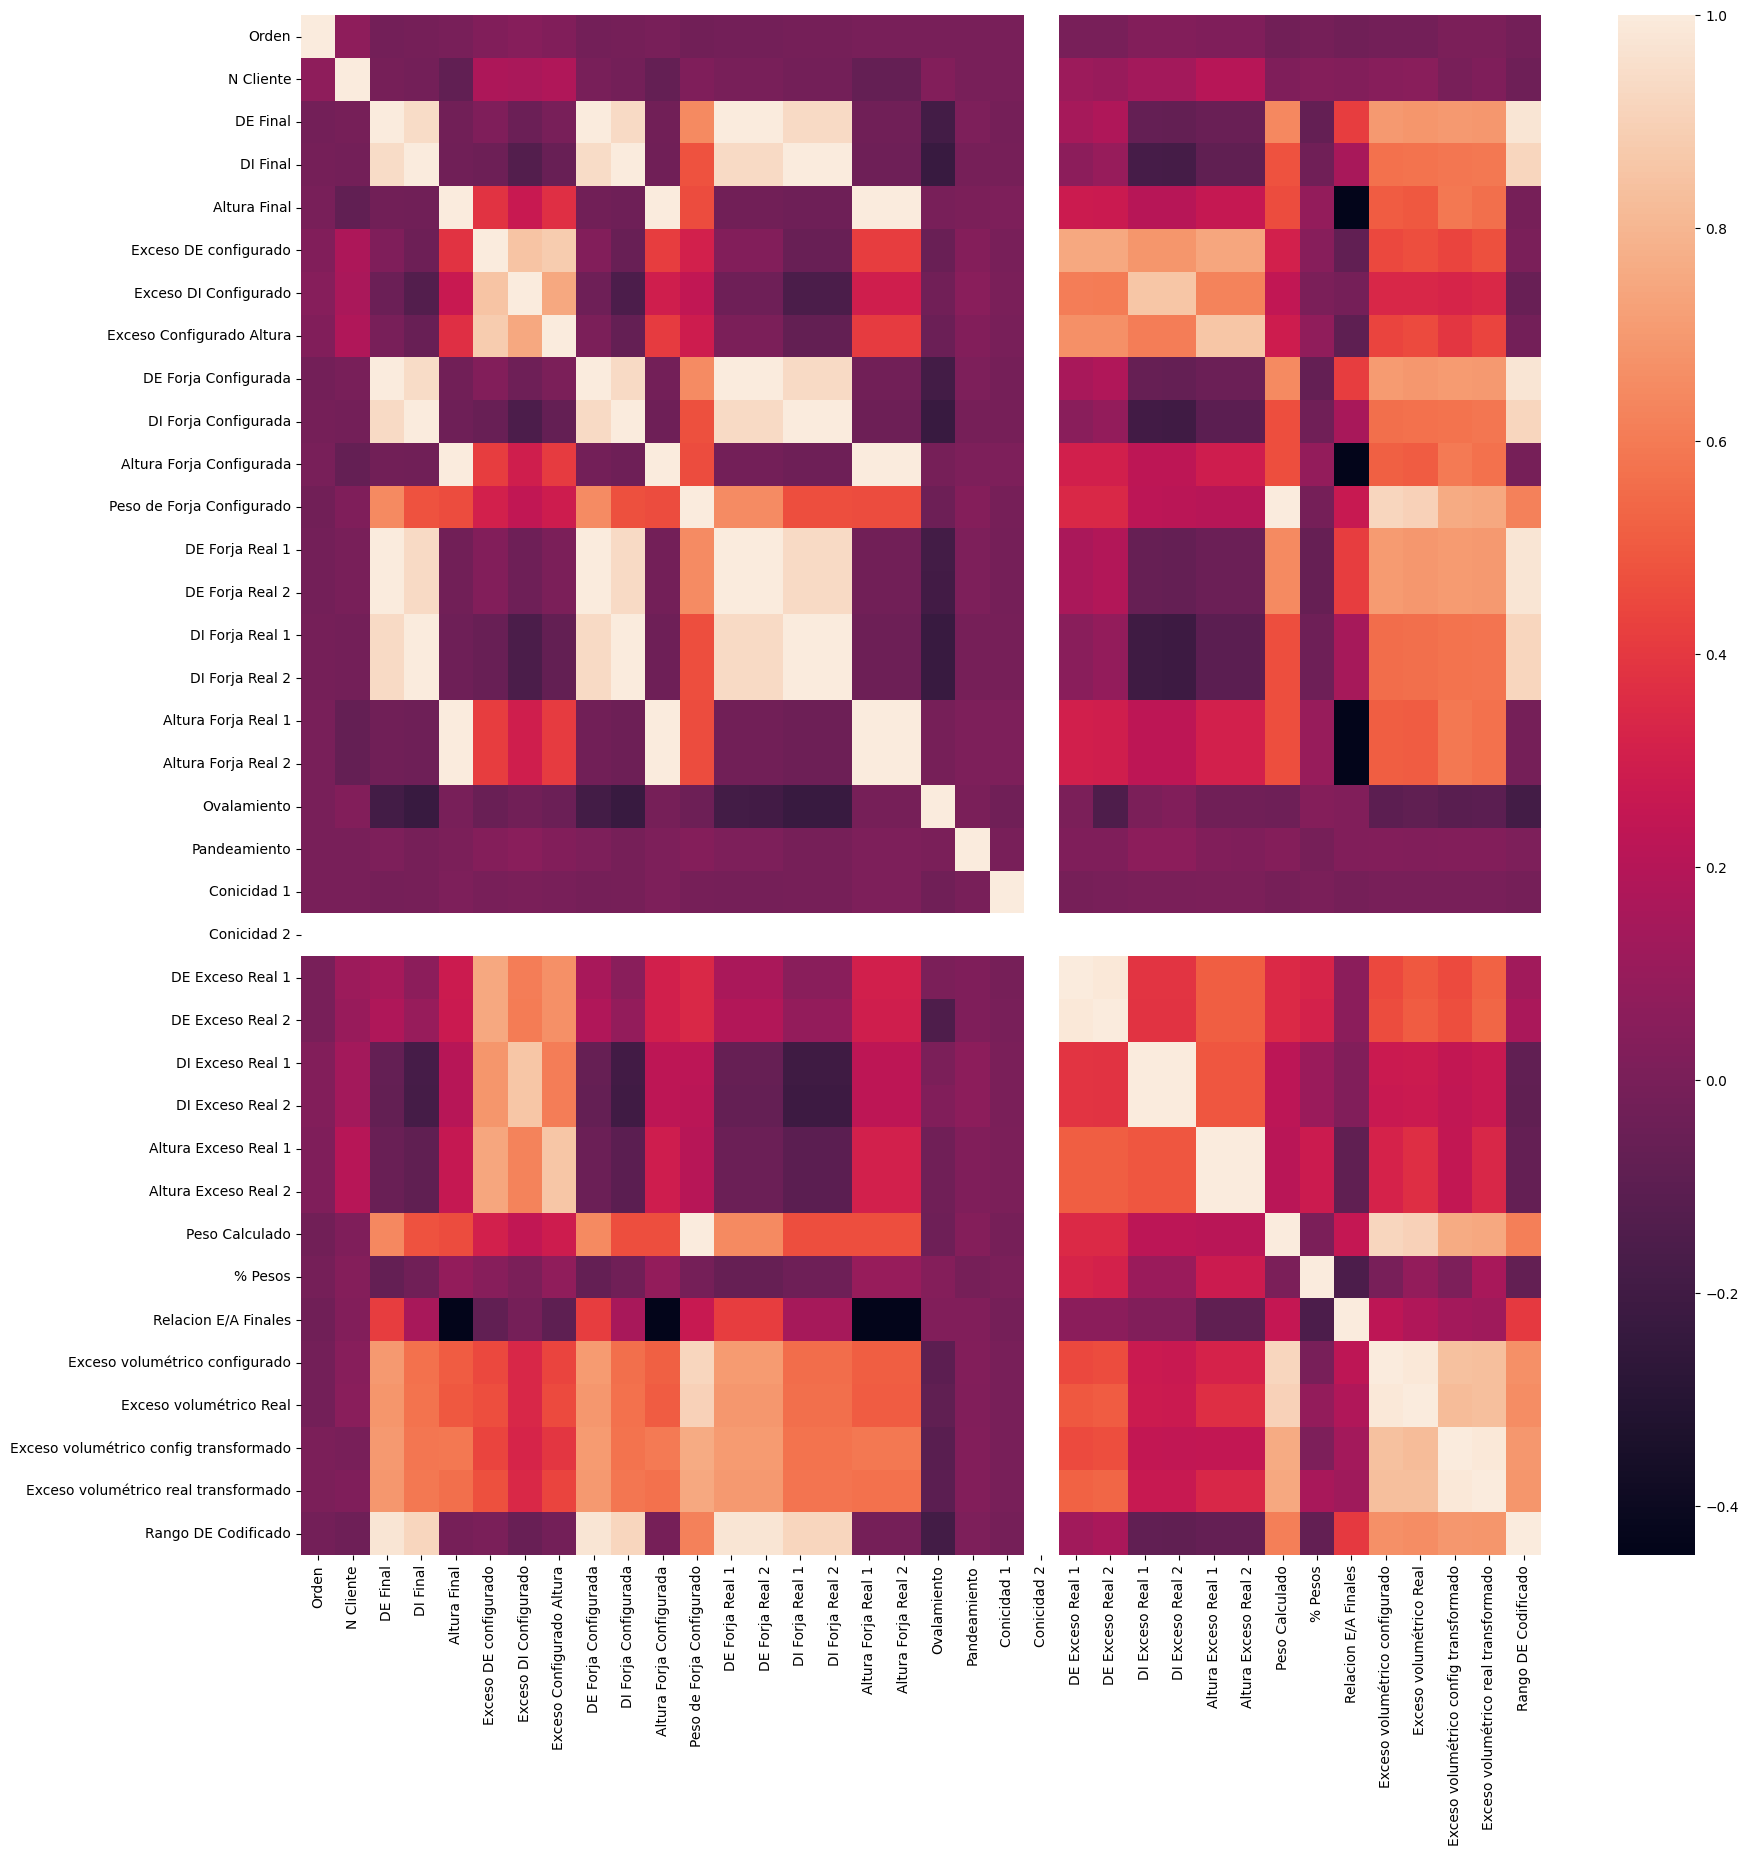

In [24]:
numericas = df_modelo.select_dtypes(include= np.number).columns
df_corr = df_modelo[numericas].corr()

fig, ax = plt.subplots(figsize=(20,20)) # Create a figure and an axes object with the desired size
sns.heatmap(df_corr, ax=ax) # Pass the axes object to seaborn.heatmap
plt.show()

Tras haber modelado dos variables como posibles predictoras del exceso volumétrico real, se usarán métodos de filtro para selección de variables para confirmar su validez.

In [25]:
test = SelectKBest(score_func = f_regression, k = 3)

X = df_modelo[numericas].drop(['Exceso volumétrico Real', 'Exceso volumétrico config transformado', 'Exceso volumétrico real transformado', 'DE Forja Real 1',	'DE Forja Real 2',	'DI Forja Real 1',	'DI Forja Real 2',	'Altura Forja Real 1',	'Altura Forja Real 2',	'Ovalamiento',	'Pandeamiento',	'Conicidad 1',	'Conicidad 2',	'DE Exceso Real 1',	'DE Exceso Real 2',	'DI Exceso Real 1',	'DI Exceso Real 2',	'Altura Exceso Real 1',	'Altura Exceso Real 2',	'Peso Calculado',	'% Pesos'], axis = 1)
y = df_modelo['Exceso volumétrico Real']

fit = test.fit(X, y)

# Resumen de los resultados
np.set_printoptions(precision=3)


features = fit.transform(X)
# Resumen de características seleccionadas

Scores_Features = pd.DataFrame({
    'Feature': X.columns,
    'Score': fit.scores_,
    'p-value': fit.pvalues_
}).sort_values('Score', ascending=False)

selected_features = X.columns[test.get_support()]
print("Características seleccionadas: ", selected_features.tolist())

Características seleccionadas:  ['DE Forja Configurada', 'Peso de Forja Configurado', 'Exceso volumétrico configurado']


In [26]:
X_Original = df_modelo[selected_features].values
y_Original = df_modelo['Exceso volumétrico Real']

Lineal = LinearRegression()
scaler = StandardScaler()
X_Original_train, X_Original_test, y_Original_train, y_Original_test = train_test_split(X_Original, y_Original, test_size=0.2, random_state=42)

X_Original_train = scaler.fit_transform(X_Original_train)
X_Original_test = scaler.transform(X_Original_test)

Lineal.fit(X_Original_train,y_Original_train)

# Ver coeficientes
print(f'Beta_0: {Lineal.intercept_:.4f}')
print(f'Beta_1:  {Lineal.coef_[0]:.4f}')
print(f'Beta_2:  {Lineal.coef_[1]:.4f}')
print(f'Beta_3:  {Lineal.coef_[2]:.4f}')


y_Original_pred = Lineal.predict(X_Original_test)

Beta_0: 53865.2281
Beta_1:  -281.7543
Beta_2:  -2251.7540
Beta_3:  54574.7859


In [27]:
mse  = mean_squared_error(y_Original_test, y_Original_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_Original_test, y_Original_pred)
mae =  mean_absolute_error(y_Original_test, y_Original_pred)
mape = mean_absolute_percentage_error(y_Original_test, y_Original_pred,)

print(f'MSE:  {mse:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'R²:   {r2:.4f}')
print(f'MAE: {mae:.4f}')
print(f'MAPE: {mape*100:.4f} %')


MSE:  59689851.3693
RMSE: 7725.9207
R²:   0.9760
MAE: 4650.8770
MAPE: 9.5978 %


In [28]:
n = X_Original_test.shape[0]  # Observaciones
p = X_Original_test.shape[1]  # Predictores
adjusted_r2 = 1 - (1 - r2) * ((n - 1) / (n - p - 1))
print(f'R² ajustado: {adjusted_r2:.4f}')

R² ajustado: 0.9760


In [29]:
# Añadir constante a las variables independiente para modelo
X_Original_train_sm = sm.add_constant(X_Original_train)

# Crear y ajustar modelo de OLS
model_sm = sm.OLS(y_Original_train, X_Original_train_sm)
results_sm = model_sm.fit()

# Imprimir modelo para ver significancia estadística (p-values)
print(results_sm.summary())

                               OLS Regression Results                              
Dep. Variable:     Exceso volumétrico Real   R-squared:                       0.975
Model:                                 OLS   Adj. R-squared:                  0.975
Method:                      Least Squares   F-statistic:                 7.536e+04
Date:                     Thu, 30 Apr 2026   Prob (F-statistic):               0.00
Time:                             15:29:20   Log-Likelihood:                -60557.
No. Observations:                     5794   AIC:                         1.211e+05
Df Residuals:                         5790   BIC:                         1.211e+05
Df Model:                                3                                         
Covariance Type:                 nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
co

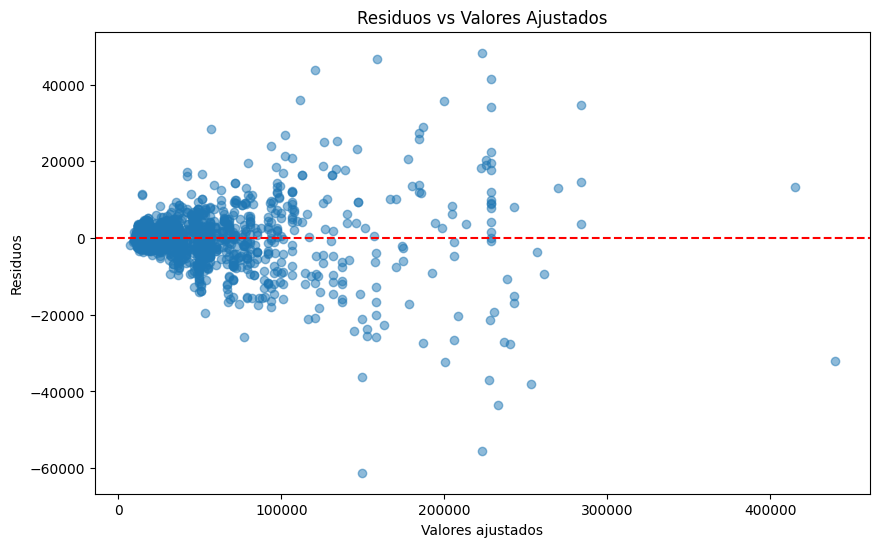

In [30]:
residuals = y_Original_test - y_Original_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_Original_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Valores ajustados')
plt.ylabel('Residuos')
plt.title('Residuos vs Valores Ajustados')
plt.show()

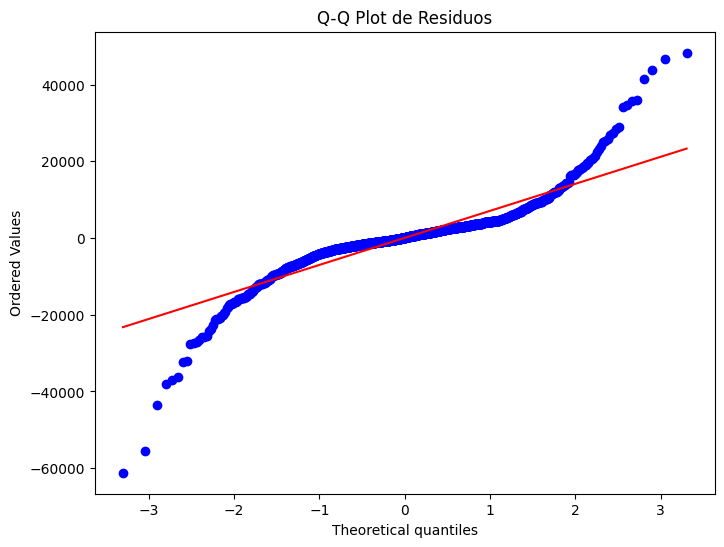

In [31]:
plt.figure(figsize=(8, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot de Residuos')
plt.show()

In [32]:
# Para el modelo 1
scores_r2 = cross_val_score(LinearRegression(), X_Original, y_Original,
                             cv=8, scoring='r2')
scores_mae = cross_val_score(LinearRegression(), X_Original, y_Original,
                               cv=8, scoring='neg_mean_absolute_error')

print(f'R² promedio (8-fold): {scores_r2.mean():.4f} ± {scores_r2.std():.4f}')
print(f'MAE promedio (8-fold): {(-scores_mae).mean():.4f} ± {(-scores_mae).std():.4f}')

R² promedio (8-fold): 0.9441 ± 0.0141
MAE promedio (8-fold): 5158.7312 ± 3382.9751


In [33]:
# Para el Modelo 1 (usar X_Original_train ya escalado)
vif_data = pd.DataFrame({
    'Feature': selected_features,
    'VIF': [variance_inflation_factor(X_Original_train, i)
            for i in range(X_Original_train.shape[1])]
}).sort_values('VIF', ascending=False)

print(vif_data)

                          Feature       VIF
2  Exceso volumétrico configurado  7.402255
1       Peso de Forja Configurado  6.515478
0            DE Forja Configurada  1.956966


Los VIF relativamente altos hacen considerar técnicas de regularización. Se evalúa regularización Ridge

In [34]:
# Buscar el mejor alpha automáticamente
ridge = Ridge()
params = {'alpha': [0.01, 0.1, 1, 10, 100]}
grid = GridSearchCV(ridge, params, cv=5, scoring='r2')
grid.fit(X_Original_train, y_Original_train)

print(f'Mejor alpha: {grid.best_params_}')
print(f'R² en test: {r2_score(y_Original_test, grid.predict(X_Original_test)):.4f}')

# Extraer el mejor modelo
best_ridge = grid.best_estimator_

# Coeficientes (ya están en escala estandarizada, igual que Lineal)
print(f'Beta_0 (intercepto): {best_ridge.intercept_:.4f}')
for i, (nombre, coef) in enumerate(zip(selected_features, best_ridge.coef_)):
    print(f'Beta_{i+1} ({nombre}): {coef:.4f}')

# Predicciones con el Ridge
y_Original_pred_ridge = best_ridge.predict(X_Original_test)

# Métricas comparativas
print(f'\n--- Comparación Lineal vs Ridge ---')
print(f'R² Lineal: {r2_score(y_Original_test, y_Original_pred):.4f}')
print(f'R² Ridge:  {r2_score(y_Original_test, y_Original_pred_ridge):.4f}')
print(f'RMSE Lineal: {np.sqrt(mean_squared_error(y_Original_test, y_Original_pred)):.4f}')
print(f'RMSE Ridge:  {np.sqrt(mean_squared_error(y_Original_test, y_Original_pred_ridge)):.4f}')

Mejor alpha: {'alpha': 0.1}
R² en test: 0.9760
Beta_0 (intercepto): 53865.2281
Beta_1 (DE Forja Configurada): -280.5052
Beta_2 (Peso de Forja Configurado): -2245.8918
Beta_3 (Exceso volumétrico configurado): 54567.5772

--- Comparación Lineal vs Ridge ---
R² Lineal: 0.9760
R² Ridge:  0.9760
RMSE Lineal: 7725.9207
RMSE Ridge:  7725.9979


In [35]:
coef_comparacion = pd.DataFrame({
    'Feature':      ['Intercepto'] + list(selected_features),
    'Coef Lineal':  [Lineal.intercept_] + list(Lineal.coef_),
    'Coef Ridge':   [best_ridge.intercept_] + list(best_ridge.coef_)
})

coef_comparacion['Cambio absoluto'] = (coef_comparacion['Coef Ridge'] - coef_comparacion['Coef Lineal']).abs()
coef_comparacion['Cambio %']        = ((coef_comparacion['Cambio absoluto'] / coef_comparacion['Coef Lineal'].abs()) * 100).round(2)

print(coef_comparacion.to_string(index=False))

                       Feature  Coef Lineal   Coef Ridge  Cambio absoluto  Cambio %
                    Intercepto 53865.228138 53865.228138         0.000000      0.00
          DE Forja Configurada  -281.754267  -280.505178         1.249089      0.44
     Peso de Forja Configurado -2251.754050 -2245.891823         5.862227      0.26
Exceso volumétrico configurado 54574.785870 54567.577190         7.208680      0.01


El bajo impacto relativo de la regularización de Ridge evidencia que la colinealidad moderadamente alta reportada por el VIF no perjudica la estabilidad del modelo, por lo que se determinó que es aceptable mantener el modelo tal cual está.

In [36]:
X = df_modelo[numericas].drop(['Exceso volumétrico Real', 'Exceso volumétrico configurado', 'Exceso volumétrico real transformado', 'DE Forja Real 1',	'DE Forja Real 2',	'DI Forja Real 1',	'DI Forja Real 2',	'Altura Forja Real 1',	'Altura Forja Real 2',	'Ovalamiento',	'Pandeamiento',	'Conicidad 1',	'Conicidad 2',	'DE Exceso Real 1',	'DE Exceso Real 2',	'DI Exceso Real 1',	'DI Exceso Real 2',	'Altura Exceso Real 1',	'Altura Exceso Real 2',	'Peso Calculado',	'% Pesos'], axis = 1)
y = df_modelo['Exceso volumétrico real transformado']

test2 = SelectKBest(score_func = f_regression, k = 3)
fit2 = test2.fit(X, y)

# Resumen de los resultados
np.set_printoptions(precision=3)


features = fit2.transform(X)
# Resumen de características seleccionadas

Score_Features2= pd.DataFrame({
    'Feature': X.columns,
    'Score': fit2.scores_,
    'p-value': fit2.pvalues_
}).sort_values('Score', ascending=False)

selected_features2 = X.columns[test2.get_support()]
print("Características seleccionadas: ", selected_features2.tolist())

Características seleccionadas:  ['DE Forja Configurada', 'Peso de Forja Configurado', 'Exceso volumétrico config transformado']


In [37]:
X_Transform = df_modelo[selected_features2].values
y_Transform = df_modelo['Exceso volumétrico real transformado']

Lineal2 = LinearRegression()
scaler2 = StandardScaler()
X_Transform_train, X_Transform_test, y_Transform_train, y_Transform_test = train_test_split(X_Transform, y_Transform, test_size=0.2, random_state=42)

X_Transform_train = scaler2.fit_transform(X_Transform_train)
X_Transform_test = scaler2.transform(X_Transform_test)

Lineal2.fit(X_Transform_train,y_Transform_train)

# Ver coeficientes
print(f'Beta_0: {Lineal2.intercept_:.4f}')
print(f'Beta_1:  {Lineal2.coef_[0]:.4f}')
print(f'Beta_2:  {Lineal2.coef_[1]:.4f}')
print(f'Beta_3:  {Lineal2.coef_[2]:.4f}')

y_Transform_pred = Lineal2.predict(X_Transform_test)

Beta_0: 0.0077
Beta_1:  0.0185
Beta_2:  -0.0030
Beta_3:  0.9744


In [38]:
# Invertir la transformación para comparar en escala real (cm³)
y_Transform_pred_real = boxcox_y.inverse_transform(
    y_Transform_pred.reshape(-1, 1)
)
y_Transform_test_real = boxcox_y.inverse_transform(
    y_Transform_test.values.reshape(-1, 1)
)


In [39]:
mse  = mean_squared_error(y_Transform_test_real, y_Transform_pred_real)
rmse = np.sqrt(mse)
r2   = r2_score(y_Transform_test_real, y_Transform_pred_real)
mae =  mean_absolute_error(y_Transform_test_real, y_Transform_pred_real)
mape = mean_absolute_percentage_error(y_Transform_test_real, y_Transform_pred_real)

print(f'MSE:  {mse:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'R²:   {r2:.4f}')
print(f'MAE: {mae:.4f}')
print(f'MAPE: {mape*100:.4f}%')


MSE:  74738337.9539
RMSE: 8645.1338
R²:   0.9700
MAE: 5043.2473
MAPE: 9.9032%


In [40]:
n = X_Transform_test.shape[0]  # Observaciones
p = X_Transform_test.shape[1]  # Predictores
adjusted_r2 = 1 - (1 - r2) * ((n - 1) / (n - p - 1))
print(f'R² ajustado: {adjusted_r2:.4f}')

R² ajustado: 0.9699


In [41]:
# Añadir constante a las variables independiente para modelo
X_Transform_train_sm = sm.add_constant(X_Transform_train)

# Crear y ajustar modelo de OLS
model_sm = sm.OLS(y_Transform_train, X_Transform_train_sm)
results_sm = model_sm.fit()

# Imprimir modelo para ver significancia estadística (p-values)
print(results_sm.summary())

                                     OLS Regression Results                                     
Dep. Variable:     Exceso volumétrico real transformado   R-squared:                       0.971
Model:                                              OLS   Adj. R-squared:                  0.971
Method:                                   Least Squares   F-statistic:                 6.372e+04
Date:                                  Thu, 30 Apr 2026   Prob (F-statistic):               0.00
Time:                                          15:29:22   Log-Likelihood:                 1996.0
No. Observations:                                  5794   AIC:                            -3984.
Df Residuals:                                      5790   BIC:                            -3957.
Df Model:                                             3                                         
Covariance Type:                              nonrobust                                         
                 coef    std e

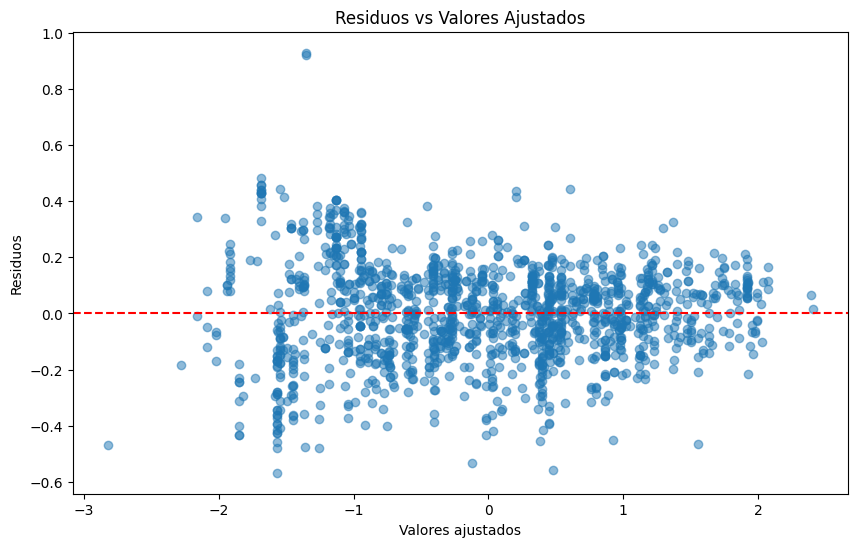

In [42]:
residuals = y_Transform_test - y_Transform_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_Transform_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Valores ajustados')
plt.ylabel('Residuos')
plt.title('Residuos vs Valores Ajustados')
plt.show()

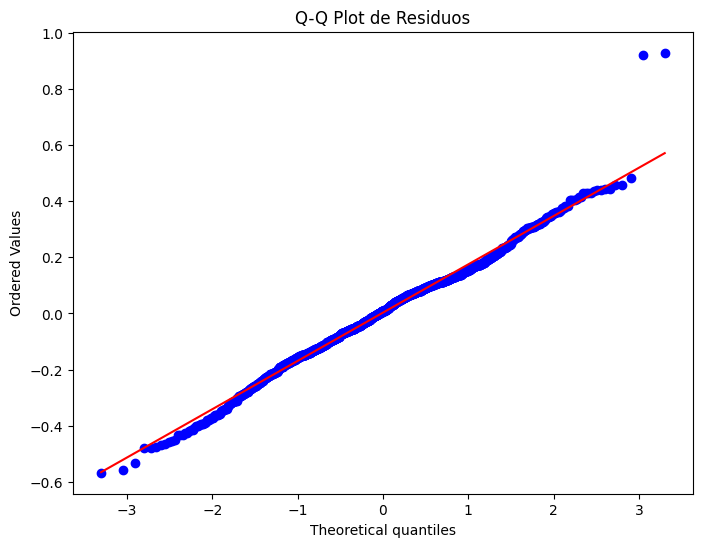

In [43]:
plt.figure(figsize=(8, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot de Residuos')
plt.show()

In [44]:
# Punto base: la media de cada feature (en escala escalada, todo ceros)
x_base = np.zeros((1, X_Transform_train.shape[1]))

# Predicción base en escala real
y_base_transformed = Lineal2.predict(x_base)
y_base_real = boxcox_y.inverse_transform(y_base_transformed.reshape(-1, 1))[0, 0]

# Efecto marginal de cada feature (perturbación de +1 desviación estándar)
efectos = {}
feature_names = ['DE Forja Configurada', 'Peso de Forja Configurado', 'Exceso vol. config transformado']

for i, nombre in enumerate(feature_names):
    x_pert = x_base.copy()
    x_pert[0, i] = 1  # +1 std en esa feature
    y_pert_transformed = Lineal2.predict(x_pert)
    y_pert_real = boxcox_y.inverse_transform(y_pert_transformed.reshape(-1, 1))[0, 0]
    efectos[nombre] = y_pert_real - y_base_real

for nombre, efecto in efectos.items():
    print(f"{nombre}: +1 std → {efecto:+.4f} cm³ en exceso real")

DE Forja Configurada: +1 std → +497.3213 cm³ en exceso real
Peso de Forja Configurado: +1 std → -79.9010 cm³ en exceso real
Exceso vol. config transformado: +1 std → +44258.5910 cm³ en exceso real


In [45]:

# Para el modelo 2
scores_r2 = cross_val_score(LinearRegression(), X_Transform, y_Transform,
                             cv=8, scoring='r2')
scores_mae = cross_val_score(LinearRegression(), X_Transform, y_Transform,
                               cv=8, scoring='neg_mean_absolute_error')

print(f'R² promedio (8-fold): {scores_r2.mean():.4f} ± {scores_r2.std():.4f}')
print(f'MAE promedio (8-fold): {(-scores_mae).mean():.4f} ± {(-scores_mae).std():.4f}')

R² promedio (8-fold): 0.9361 ± 0.0185
MAE promedio (8-fold): 0.1389 ± 0.0216


Cross Validation confirmó la robustez del modelo, manteniendo un MAE bajo en promedio en las 8 particiones evaluadas

In [46]:
# Para el Modelo 2 (usar X_Transform_train ya escalado)
vif_data2 = pd.DataFrame({
    'Feature': selected_features2,  # o selected_features2 si tienes nombre distinto
    'VIF': [variance_inflation_factor(X_Transform_train, i)
            for i in range(X_Transform_train.shape[1])]
}).sort_values('VIF', ascending=False)

print(vif_data2)

                                  Feature       VIF
2  Exceso volumétrico config transformado  2.928351
1               Peso de Forja Configurado  2.568374
0                    DE Forja Configurada  2.085783


Dado que el VIF es bajo, no se considera necesario usar técnicas de regularización

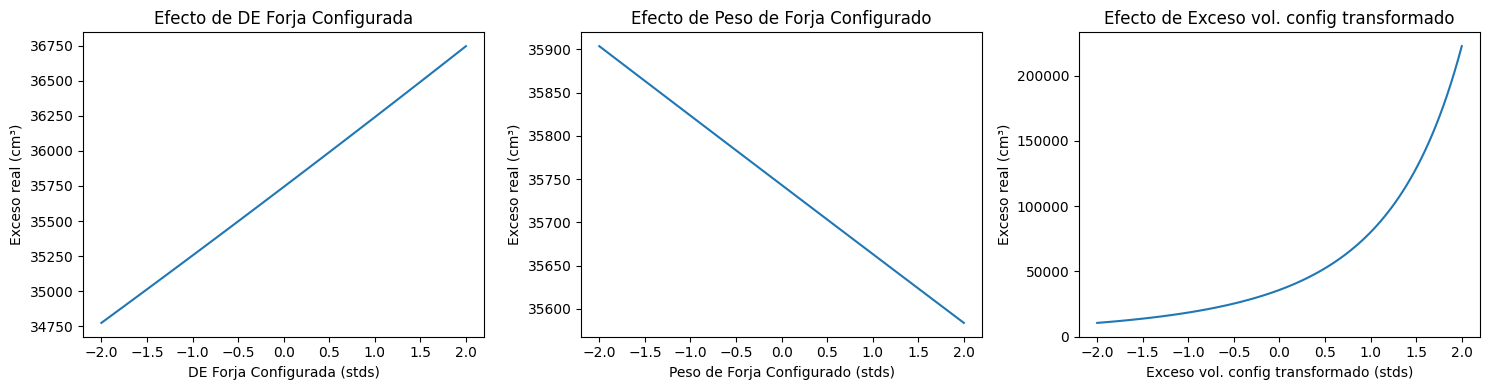

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (nombre, ax) in enumerate(zip(feature_names, axes)):
    # Barrido de -2 a +2 stds para esa feature, el resto en 0
    vals = np.linspace(-2, 2, 100)
    x_sweep = np.zeros((100, 3))
    x_sweep[:, i] = vals

    y_pred_t = Lineal2.predict(x_sweep)
    y_pred_real = boxcox_y.inverse_transform(y_pred_t.reshape(-1, 1))

    ax.plot(vals, y_pred_real)
    ax.set_xlabel(f'{nombre} (stds)')
    ax.set_ylabel('Exceso real (cm³)')
    ax.set_title(f'Efecto de {nombre}')

plt.tight_layout()
plt.show()

Dado el p value alto de x_2, se evalúa modelo de regresión alternativo en el que se excluye esta variable

In [48]:
X_Transform = df_modelo[['DE Forja Configurada', 'Exceso volumétrico config transformado']].values
y_Transform = df_modelo['Exceso volumétrico real transformado']

Lineal2 = LinearRegression()
scaler2 = StandardScaler()
X_Transform_train, X_Transform_test, y_Transform_train, y_Transform_test = train_test_split(X_Transform, y_Transform, test_size=0.2, random_state=42)

X_Transform_train = scaler2.fit_transform(X_Transform_train)
X_Transform_test = scaler2.transform(X_Transform_test)

Lineal2.fit(X_Transform_train,y_Transform_train)

# Ver coeficientes
print(f'Beta_0: {Lineal2.intercept_:.4f}')
print(f'Beta_1:  {Lineal2.coef_[0]:.4f}')
print(f'Beta_2:  {Lineal2.coef_[1]:.4f}')

y_Transform_pred = Lineal2.predict(X_Transform_test)

Beta_0: 0.0077
Beta_1:  0.0179
Beta_2:  0.9726


In [49]:
# Invertir la transformación para comparar en escala real (cm³)
y_Transform_pred_real = boxcox_y.inverse_transform(
    y_Transform_pred.reshape(-1, 1)
)
y_Transform_test_real = boxcox_y.inverse_transform(
    y_Transform_test.values.reshape(-1, 1)
)


In [50]:
mse  = mean_squared_error(y_Transform_test_real, y_Transform_pred_real)
rmse = np.sqrt(mse)
r2   = r2_score(y_Transform_test_real, y_Transform_pred_real)
mae =  mean_absolute_error(y_Transform_test_real, y_Transform_pred_real)
mape = mean_absolute_percentage_error(y_Transform_test_real, y_Transform_pred_real)

print(f'MSE:  {mse:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'R²:   {r2:.4f}')
print(f'MAE: {mae:.4f}')
print(f'MAPE: {mape*100:.4f}%')


MSE:  73066981.6987
RMSE: 8547.9227
R²:   0.9707
MAE: 5020.6596
MAPE: 9.9027%


In [51]:
n = X_Transform_test.shape[0]  # Observaciones
p = X_Transform_test.shape[1]  # Predictores
adjusted_r2 = 1 - (1 - r2) * ((n - 1) / (n - p - 1))
print(f'R² ajustado: {adjusted_r2:.4f}')

R² ajustado: 0.9706


In [52]:
# Añadir constante a las variables independiente para modelo
X_Transform_train_sm = sm.add_constant(X_Transform_train)

# Crear y ajustar modelo de OLS
model_sm = sm.OLS(y_Transform_train, X_Transform_train_sm)
results_sm = model_sm.fit()

# Imprimir modelo para ver significancia estadística (p-values)
print(results_sm.summary())

                                     OLS Regression Results                                     
Dep. Variable:     Exceso volumétrico real transformado   R-squared:                       0.971
Model:                                              OLS   Adj. R-squared:                  0.971
Method:                                   Least Squares   F-statistic:                 9.559e+04
Date:                                  Thu, 30 Apr 2026   Prob (F-statistic):               0.00
Time:                                          15:29:26   Log-Likelihood:                 1995.6
No. Observations:                                  5794   AIC:                            -3985.
Df Residuals:                                      5791   BIC:                            -3965.
Df Model:                                             2                                         
Covariance Type:                              nonrobust                                         
                 coef    std e

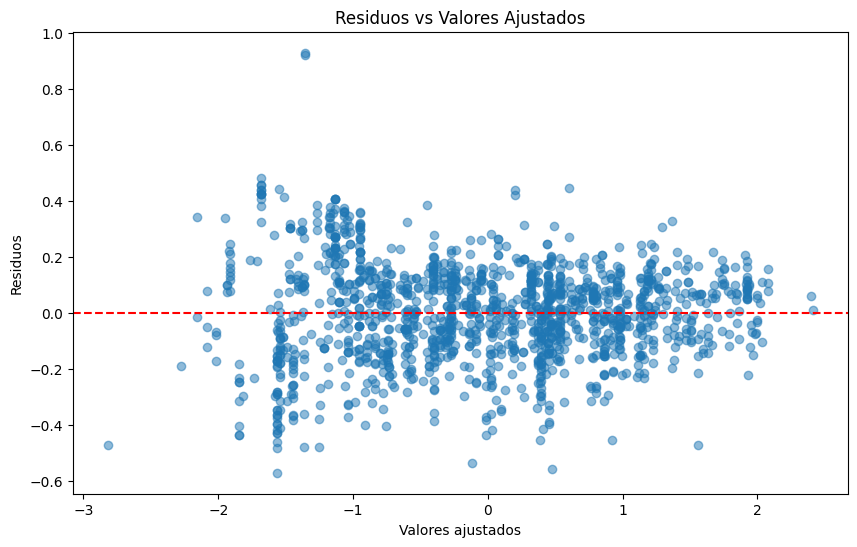

In [53]:
residuals = y_Transform_test - y_Transform_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_Transform_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Valores ajustados')
plt.ylabel('Residuos')
plt.title('Residuos vs Valores Ajustados')
plt.show()

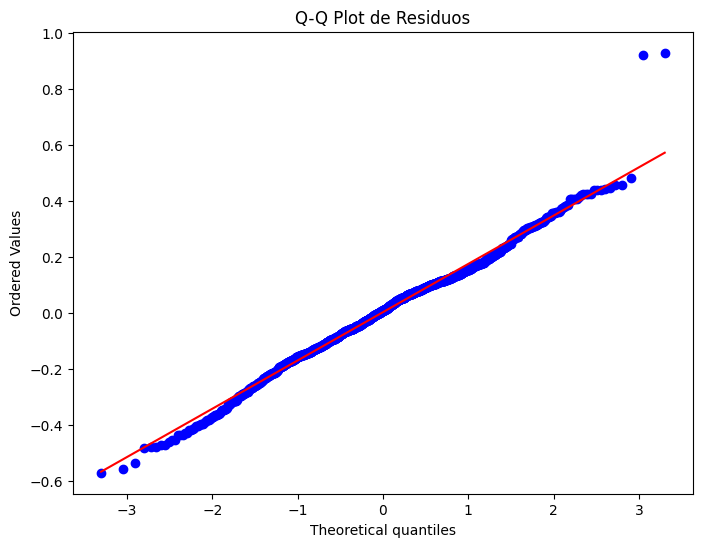

In [54]:
import scipy.stats as stats

plt.figure(figsize=(8, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot de Residuos')
plt.show()

In [55]:
# Punto base: la media de cada feature (en escala escalada, todo ceros)
x_base = np.zeros((1, X_Transform_train.shape[1]))

# Predicción base en escala real
y_base_transformed = Lineal2.predict(x_base)
y_base_real = boxcox_y.inverse_transform(y_base_transformed.reshape(-1, 1))[0, 0]

# Efecto marginal de cada feature (perturbación de +1 desviación estándar)
efectos = {}
feature_names = ['DE Forja Configurada', 'Exceso vol. config transformado']

for i, nombre in enumerate(feature_names):
    x_pert = x_base.copy()
    x_pert[0, i] = 1  # +1 std en esa feature
    y_pert_transformed = Lineal2.predict(x_pert)
    y_pert_real = boxcox_y.inverse_transform(y_pert_transformed.reshape(-1, 1))[0, 0]
    efectos[nombre] = y_pert_real - y_base_real

for nombre, efecto in efectos.items():
    print(f"{nombre}: +1 std → {efecto:+.4f} cm³ en exceso real")

DE Forja Configurada: +1 std → +479.5603 cm³ en exceso real
Exceso vol. config transformado: +1 std → +44123.0844 cm³ en exceso real


In [56]:

# Para el modelo 2
scores_r2 = cross_val_score(LinearRegression(), X_Transform, y_Transform,
                             cv=8, scoring='r2')
scores_mae = cross_val_score(LinearRegression(), X_Transform, y_Transform,
                               cv=8, scoring='neg_mean_absolute_error')

print(f'R² promedio (8-fold): {scores_r2.mean():.4f} ± {scores_r2.std():.4f}')
print(f'MAE promedio (8-fold): {(-scores_mae).mean():.4f} ± {(-scores_mae).std():.4f}')

R² promedio (8-fold): 0.9379 ± 0.0196
MAE promedio (8-fold): 0.1365 ± 0.0233


In [57]:
# Para el Modelo 2 (usar X_Transform_train ya escalado)
vif_data2 = pd.DataFrame({
    'Feature': ['DE Forja Configurada', 'Exceso volumétrico config transformado'],  # o selected_features2 si tienes nombre distinto
    'VIF': [variance_inflation_factor(X_Transform_train, i)
            for i in range(X_Transform_train.shape[1])]
}).sort_values('VIF', ascending=False)

print(vif_data2)

                                  Feature       VIF
1  Exceso volumétrico config transformado  1.963498
0                    DE Forja Configurada  1.963498


Dado que el VIF es bajo, no se considera necesario evaluar métodos de regularización

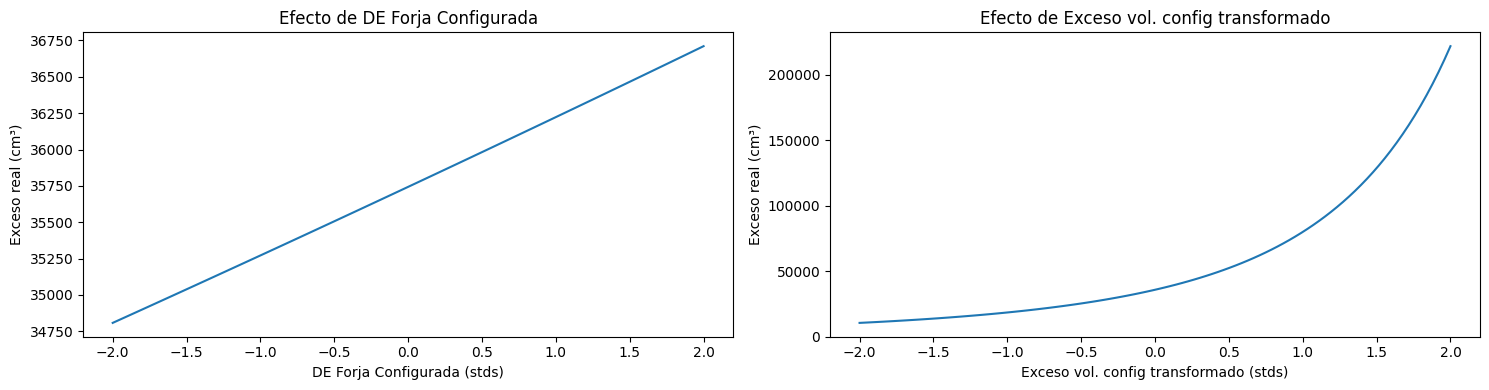

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

for i, (nombre, ax) in enumerate(zip(feature_names, axes)):
    # Barrido de -2 a +2 stds para esa feature, el resto en 0
    vals = np.linspace(-2, 2, 100)
    x_sweep = np.zeros((100, 2))
    x_sweep[:, i] = vals

    y_pred_t = Lineal2.predict(x_sweep)
    y_pred_real = boxcox_y.inverse_transform(y_pred_t.reshape(-1, 1))

    ax.plot(vals, y_pred_real)
    ax.set_xlabel(f'{nombre} (stds)')
    ax.set_ylabel('Exceso real (cm³)')
    ax.set_title(f'Efecto de {nombre}')

plt.tight_layout()
plt.show()

# Modelo 2

Dado que el interés es reducir el exceso, se propondrá un modelo de clasificación que determina que piezas tienen mayor probabilidad de estar por encima de un umbral de exceso específico, y luego se propondrá un modelo de clasificación basado en árboles de decisión que separe los datos con mayor posibilidad de superar ese umbral.

In [59]:
#Determinación del umbral
# Ratio: qué tanto excedió la pieza respecto a lo configurado
df_modelo['Ratio exceso'] = df_modelo['Exceso volumétrico Real'] / df_modelo['Exceso volumétrico configurado']

# Explora la distribución del ratio
df_modelo['Ratio exceso'].describe()

,Ratio exceso
count,7243.000000
mean,1.207283
std,0.159025
min,0.597943
25%,1.102955
50%,1.191439
75%,1.297427
max,2.282073


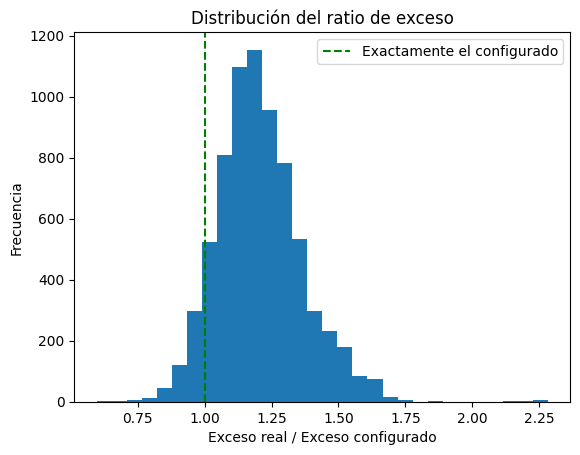

In [60]:
plt.hist(df_modelo['Ratio exceso'], bins=30)
plt.axvline(x=1.0, color='green', linestyle='--', label='Exactamente el configurado')
plt.xlabel('Exceso real / Exceso configurado')
plt.ylabel('Frecuencia')
plt.title('Distribución del ratio de exceso')
plt.legend()
plt.show()

In [61]:
umbrales = [0.9, 1, 1.1, 1.15, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2, 2.1, 2.2, 2.25]
print(df_modelo['Calidad'].value_counts())

for i in umbrales:
    # Crosstab: ratio alto coincide con rechazos?
    df_modelo[f'Ratio > {i}'] = df_modelo['Ratio exceso'] > i # prueba distintos umbrales

    print(pd.crosstab(df_modelo[f'Ratio > {i}'], df_modelo['Calidad']))

Calidad
Pieza buena    7157
Reproceso        65
Rechazo          21
Name: count, dtype: int64
Calidad      Pieza buena  Rechazo  Reproceso
Ratio > 0.9                                 
False                 95        0          5
True                7062       21         60
Calidad    Pieza buena  Rechazo  Reproceso
Ratio > 1                                 
False              527        3         12
True              6630       18         53
Calidad      Pieza buena  Rechazo  Reproceso
Ratio > 1.1                                 
False               1717        8         25
True                5440       13         40
Calidad       Pieza buena  Rechazo  Reproceso
Ratio > 1.15                                 
False                2658       12         37
True                 4499        9         28
Calidad      Pieza buena  Rechazo  Reproceso
Ratio > 1.2                                 
False               3724       17         45
True                3433        4         20
Calidad   

Dado que se busca reducir el exceso, se escoge 1.1, que permitirá una mejor clasificasión para el modelo

In [62]:
umbral_ratio = 1.1

df_modelo['Clase'] = (df_modelo['Ratio exceso'] > umbral_ratio).astype(int)
# 0 = exceso aceptable, 1 = exceso excesivo

print(df_modelo['Clase'].value_counts())
print(f"% piezas con exceso de más: {df_modelo['Clase'].mean()*100:.1f}%")

Clase
1    5493
0    1750
Name: count, dtype: int64
% piezas con exceso de más: 75.8%


In [63]:
test3 = RFE(estimator = DecisionTreeClassifier(), n_features_to_select=4)

X = df_modelo[numericas].drop(['Exceso volumétrico Real', 'Exceso volumétrico real transformado', 'DE Forja Real 1',	'DE Forja Real 2',	'DI Forja Real 1',	'DI Forja Real 2',	'Altura Forja Real 1',	'Altura Forja Real 2',	'Ovalamiento',	'Pandeamiento',	'Conicidad 1',	'Conicidad 2',	'DE Exceso Real 1',	'DE Exceso Real 2',	'DI Exceso Real 1',
                               'DI Exceso Real 2',	'Altura Exceso Real 1',	'Altura Exceso Real 2',	'Peso Calculado',	'% Pesos', 'Orden', 'N Cliente'], axis = 1)
y = df_modelo['Clase']
fit3 = test3.fit(X, y)

# Resumen de los resultados
np.set_printoptions(precision=3)


features3 = fit3.transform(X)
# Resumen de características seleccionadas
Scores_Features3 = pd.DataFrame({
    'Feature': X.columns,
    'Rank': fit3.ranking_
}).sort_values('Rank', ascending=True) # Sort by rank ascending, as lower rank means more important (selected)

selected_features3 = X.columns[test3.get_support()]
print("Características seleccionadas: ", selected_features3.tolist())
print("\nResumen de Ranking de Características:")
print(Scores_Features3)

Características seleccionadas:  ['Exceso DI Configurado', 'Peso de Forja Configurado', 'Relacion E/A Finales', 'Exceso volumétrico configurado']

Resumen de Ranking de Características:
                                   Feature  Rank
4                    Exceso DI Configurado     1
11          Exceso volumétrico configurado     1
10                    Relacion E/A Finales     1
9                Peso de Forja Configurado     1
7                     DI Forja Configurada     2
8                 Altura Forja Configurada     3
2                             Altura Final     4
1                                 DI Final     5
12  Exceso volumétrico config transformado     6
0                                 DE Final     7
5                Exceso Configurado Altura     8
6                     DE Forja Configurada     9
3                    Exceso DE configurado    10
13                     Rango DE Codificado    11


# Arbol de decision

In [64]:

X_clasif = df_modelo[ selected_features3]
y_clasif = df_modelo['Clase']

X_clasif_train, X_clasif_test, y_clasif_train, y_clasif_test = train_test_split(X_clasif, y_clasif, stratify= y_clasif, test_size= 0.2, random_state = 42)


tree = DecisionTreeClassifier(
    class_weight='balanced'
)

# 3. Usar GridSearchCV optimizando f1
from sklearn.model_selection import GridSearchCV
grid1 = GridSearchCV(
    tree,
    param_grid={
        'criterion': ['entropy', 'gini'],
        'max_depth': [5,6,7,8],
        'min_samples_leaf': [5, 6, 7, 8, 9, 10],
        'min_impurity_decrease': [0.0005, 0.0006, 0.0008, 0.0009, 0.001, 0.005]  # explorar valores suaves
    },
    scoring='f1',
    cv=5
)
grid1.fit(X_clasif_train, y_clasif_train)
best_tree1 = grid1.best_estimator_

y_clasid_pred = best_tree1.predict(X_clasif_test)
y_clasif_prob = best_tree1.predict_proba(X_clasif_test)[:, 1]

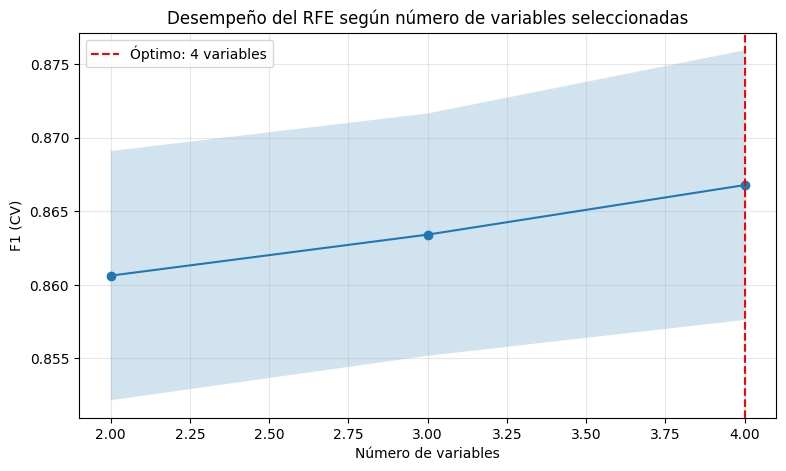

Número óptimo de variables: 4
Variables seleccionadas: ['Exceso DI Configurado', 'Peso de Forja Configurado', 'Relacion E/A Finales', 'Exceso volumétrico configurado']


In [65]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rfecv = RFECV(
    estimator=DecisionTreeClassifier(class_weight='balanced', random_state=42),
    step=1,
    cv=cv,
    scoring='f1',        # o 'precision' según tu métrica prioritaria
    min_features_to_select=2
)
rfecv.fit(X_clasif_train, y_clasif_train)

# ── Curva de desempeño ───────────────────────────────────────────────────────
plt.figure(figsize=(9, 5))
plt.plot(
    range(rfecv.min_features_to_select, len(rfecv.cv_results_['mean_test_score']) + rfecv.min_features_to_select),
    rfecv.cv_results_['mean_test_score'],
    marker='o'
)
plt.fill_between(
    range(rfecv.min_features_to_select, len(rfecv.cv_results_['mean_test_score']) + rfecv.min_features_to_select),
    rfecv.cv_results_['mean_test_score'] - rfecv.cv_results_['std_test_score'],
    rfecv.cv_results_['mean_test_score'] + rfecv.cv_results_['std_test_score'],
    alpha=0.2
)
plt.axvline(rfecv.n_features_, color='red', linestyle='--', label=f'Óptimo: {rfecv.n_features_} variables')
plt.xlabel('Número de variables')
plt.ylabel('F1 (CV)')
plt.title('Desempeño del RFE según número de variables seleccionadas')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ── Variables seleccionadas ──────────────────────────────────────────────────
features_seleccionadas = X_clasif_train.columns[rfecv.support_].tolist()
print(f"Número óptimo de variables: {rfecv.n_features_}")
print(f"Variables seleccionadas: {features_seleccionadas}")

In [66]:
df_modelo[['DI Final', 'Exceso DI Configurado', 'Altura Forja Configurada', 'Peso de Forja Configurado', 'Exceso volumétrico config transformado']].corr()

,DI Final,Exceso DI Configurado,Altura Forja Configurada,Peso de Forja Configurado,Exceso volumétrico config transformado
DI Final,1.000000,-0.134296,-0.032790,0.477769,0.584214
Exceso DI Configurado,-0.134296,1.000000,0.296180,0.238788,0.323772
Altura Forja Configurada,-0.032790,0.296180,1.000000,0.463243,0.595244
Peso de Forja Configurado,0.477769,0.238788,0.463243,1.000000,0.762412
Exceso volumétrico config transformado,0.584214,0.323772,0.595244,0.762412,1.000000


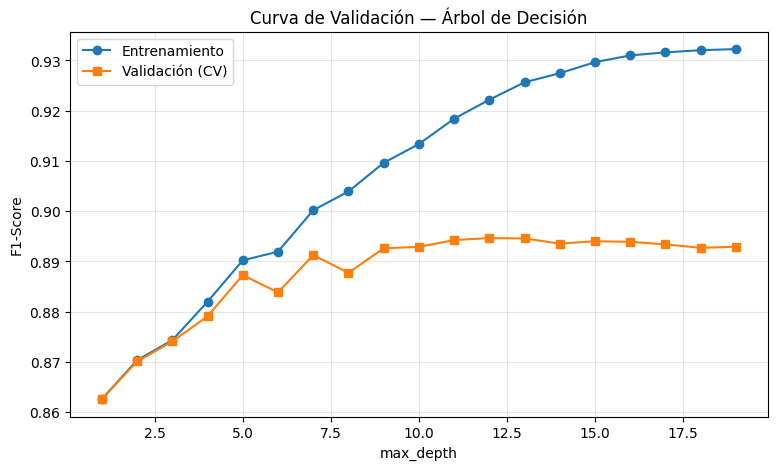

In [67]:
depths = range(1, 20)
train_scores, val_scores = validation_curve(
    DecisionTreeClassifier(criterion='entropy', random_state=42),
    X_clasif_train, y_clasif_train,
    param_name='max_depth', param_range=depths,
    cv=5, scoring='f1'
)

plt.figure(figsize=(9, 5))
plt.plot(depths, train_scores.mean(axis=1), label='Entrenamiento', marker='o')
plt.plot(depths, val_scores.mean(axis=1),   label='Validación (CV)', marker='s')
plt.xlabel('max_depth')
plt.ylabel('F1-Score')
plt.title('Curva de Validación — Árbol de Decisión')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [68]:
# Mejor combinación de hiperparámetros
print(grid1.best_params_)

# Mejor score (recall) obtenido en CV
print(grid1.best_score_)

# El mejor modelo ya listo para usar
best_tree1 = grid1.best_estimator_

# Tabla completa con todos los resultados
resultados = pd.DataFrame(grid1.cv_results_)
print(resultados[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
      .sort_values('rank_test_score'))

# Predicciones con el mejor modelo
y_pred = best_tree1.predict(X_clasif_test)

# Métricas finales
print(f"Recall:    {recall_score(y_clasif_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_clasif_test, y_pred):.4f}")
print(f"F1:        {f1_score(y_clasif_test, y_pred):.4f}")

{'criterion': 'entropy', 'max_depth': 8, 'min_impurity_decrease': 0.0005, 'min_samples_leaf': 5}
0.826953945698121
                                                params  mean_test_score  \
108  {'criterion': 'entropy', 'max_depth': 8, 'min_...         0.826954   
72   {'criterion': 'entropy', 'max_depth': 7, 'min_...         0.826889   
73   {'criterion': 'entropy', 'max_depth': 7, 'min_...         0.826249   
109  {'criterion': 'entropy', 'max_depth': 8, 'min_...         0.826239   
78   {'criterion': 'entropy', 'max_depth': 7, 'min_...         0.826218   
..                                                 ...              ...   
161  {'criterion': 'gini', 'max_depth': 5, 'min_imp...         0.782639   
155  {'criterion': 'gini', 'max_depth': 5, 'min_imp...         0.782639   
173  {'criterion': 'gini', 'max_depth': 5, 'min_imp...         0.782639   
167  {'criterion': 'gini', 'max_depth': 5, 'min_imp...         0.782639   
149  {'criterion': 'gini', 'max_depth': 5, 'min_imp...      

Por Grid Search se determinó que {'criterion': 'entropy', 'max_depth': 8, 'min_impurity_decrease': 0.0005, 'min_samples_leaf': 10} son los hiperparámetros mejores

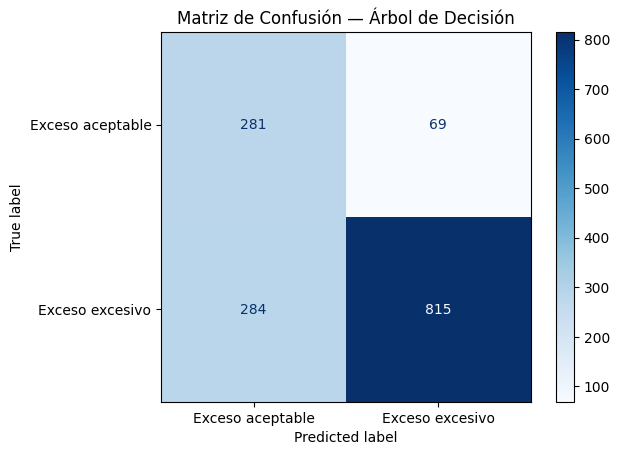

In [69]:
# ── 1. MATRIZ DE CONFUSIÓN ──────────────────────────────────────────────────
confusion_Mat = confusion_matrix(y_clasif_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_Mat,
                               display_labels=['Exceso aceptable', 'Exceso excesivo'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión — Árbol de Decisión')
plt.show()


In [70]:
# ── 2. MÉTRICAS ─────────────────────────────────────────────────────────────
accuracy  = accuracy_score(y_clasif_test, y_pred)
precision = precision_score(y_clasif_test, y_pred)
recall    = recall_score(y_clasif_test, y_pred)
f1        = f1_score(y_clasif_test, y_pred)

print(f'Accuracy:  {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1-Score:  {f1:.4f}')

Accuracy:  0.7564
Precision: 0.9219
Recall:    0.7416
F1-Score:  0.8220


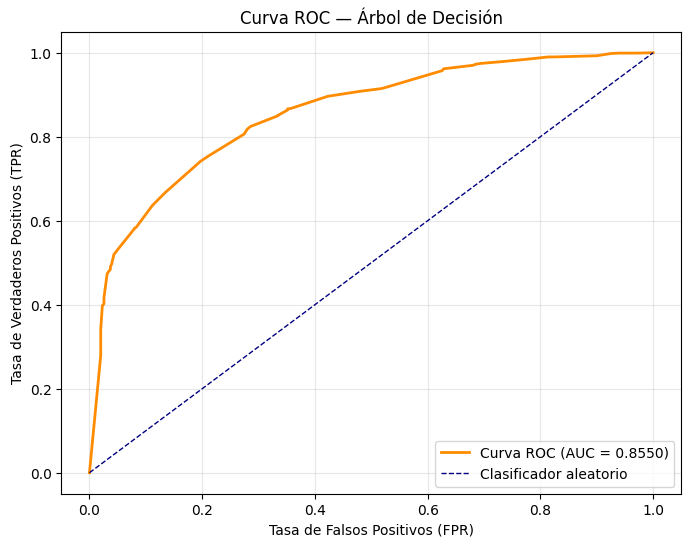

AUC: 0.8550


In [71]:
# ── 3. CURVA ROC Y AUC ──────────────────────────────────────────────────────
# Se necesitan las probabilidades (no las clases predichas)
y_clasif_prob = best_tree1.predict_proba(X_clasif_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_clasif_test, y_clasif_prob)
auc_score = roc_auc_score(y_clasif_test, y_clasif_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'Curva ROC (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--',
         label='Clasificador aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC — Árbol de Decisión')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

print(f'AUC: {auc_score:.4f}')

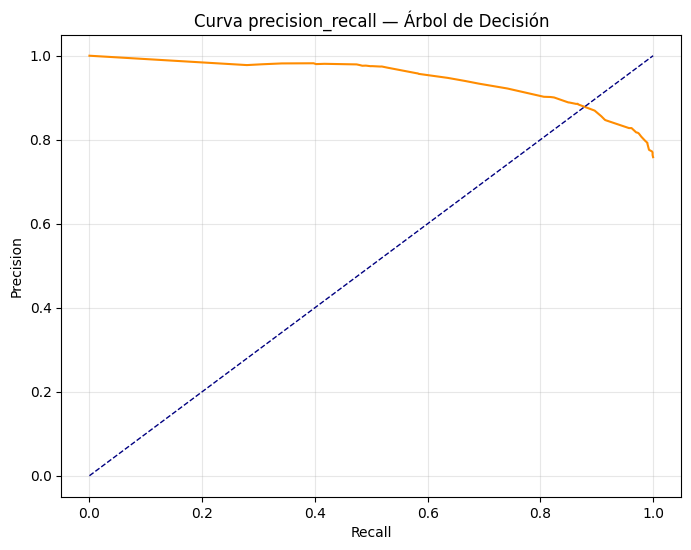

0.0


In [72]:
precisiones, recalls, umbrales = precision_recall_curve(
    y_clasif_test,
    best_tree1.predict_proba(X_clasif_test)[:, 1]
)
plt.figure(figsize=(8, 6))
plt.plot( recalls, precisiones, color='darkorange')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--',
         label='Clasificador aleatorio')
plt.ylabel('Precision')
plt.xlabel('Recall')
plt.title('Curva precision_recall — Árbol de Decisión')

plt.grid(alpha=0.3)
plt.show()
# Encontrar umbral que maximiza precisión con recall mínimo aceptable
umbral_optimo = umbrales[np.where(recalls[:-1] >= 0.4)[0][recalls[np.where(recalls[:-1] >= 0.4)].argmax()]]
print(umbral_optimo)

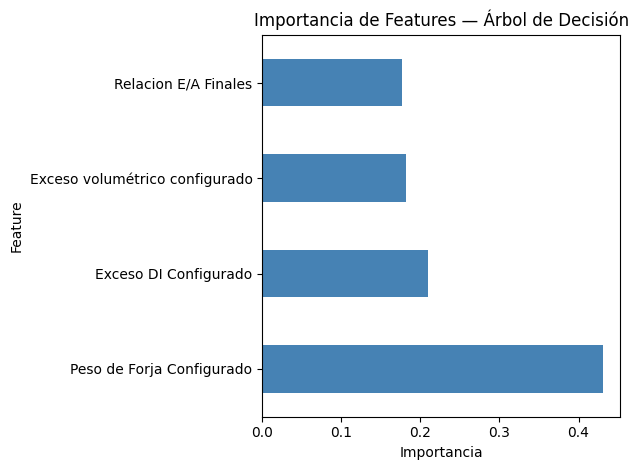

In [73]:
importancias = pd.DataFrame({
    'Feature':     selected_features3,
    'Importancia': best_tree1.feature_importances_
}).sort_values('Importancia', ascending=False)

importancias.plot(kind='barh', x='Feature', y='Importancia',
                  legend=False, color='steelblue')
plt.title('Importancia de Features — Árbol de Decisión')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

In [74]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
importancias_cv = []

for train_idx, _ in cv.split(X_clasif_train, y_clasif_train):
    arbol_cv = DecisionTreeClassifier(**grid1.best_params_,
                                       class_weight='balanced',
                                       random_state=42)
    arbol_cv.fit(X_clasif_train.iloc[train_idx],
                 y_clasif_train.iloc[train_idx])
    importancias_cv.append(arbol_cv.feature_importances_)

importancias_cv = np.array(importancias_cv)

tabla_importancia = pd.DataFrame({
    'Variable':              selected_features3,
    'Importancia media':     importancias_cv.mean(axis=0),
    'Desv. estándar (CV)':  importancias_cv.std(axis=0),
    'IC 95% inferior':      importancias_cv.mean(axis=0) - 1.96 * importancias_cv.std(axis=0),
    'IC 95% superior':      importancias_cv.mean(axis=0) + 1.96 * importancias_cv.std(axis=0),
}).sort_values('Importancia media', ascending=False)

print(tabla_importancia.to_string(index=False))

                      Variable  Importancia media  Desv. estándar (CV)  IC 95% inferior  IC 95% superior
     Peso de Forja Configurado           0.433958             0.022126         0.390591         0.477324
         Exceso DI Configurado           0.218352             0.010440         0.197889         0.238815
          Relacion E/A Finales           0.174104             0.023031         0.128963         0.219245
Exceso volumétrico configurado           0.173586             0.025481         0.123644         0.223529


La importancia de las Features utilizadas justifica su elección y el mantenerlas todas.

In [75]:
viz = model(best_tree1, X_clasif_train, y_clasif_train,
            target_name= 'Clase',
                feature_names=X_clasif_train.columns,
                 class_names=['Exceso aceptable', 'Exceso excesivo'])

viz.view()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names


# Arbol 2

In [76]:

X_clasif = df_modelo[ selected_features3]
y_clasif = df_modelo['Clase']

X_clasif_train, X_clasif_test, y_clasif_train, y_clasif_test = train_test_split(X_clasif, y_clasif, stratify= y_clasif, test_size= 0.2, random_state = 42)


tree = DecisionTreeClassifier(
    class_weight='balanced'
)

# 3. Usar GridSearchCV optimizando f1
grid2 = GridSearchCV(
    tree,
    param_grid={
        'criterion': ['entropy', 'gini'],
        'max_depth': [5,6,7,8,9,10],
        'min_samples_leaf': [5, 6, 7, 8, 9, 10],
        'min_impurity_decrease': [0.0005, 0.0006, 0.0008, 0.0009, 0.001, 0.005]  # explorar valores suaves
    },
    scoring='f1',
    cv=5
)
grid2.fit(X_clasif_train, y_clasif_train)
best_tree2 = grid2.best_estimator_

y_clasid_pred = best_tree2.predict(X_clasif_test)
y_clasif_prob = best_tree2.predict_proba(X_clasif_test)[:, 1]

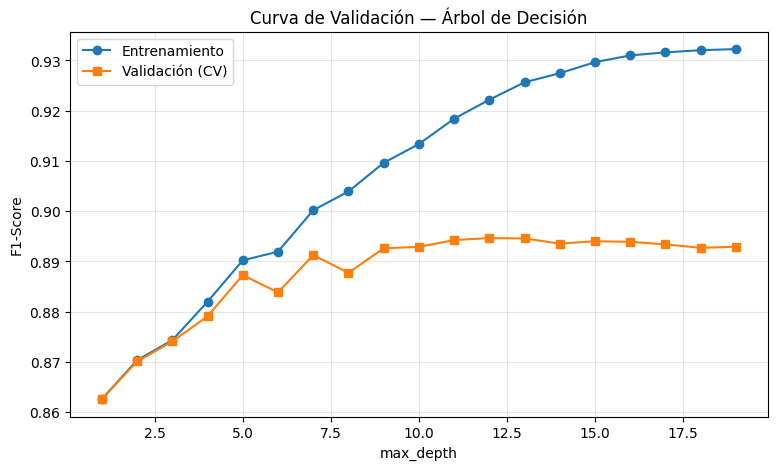

In [77]:
depths = range(1, 20)
train_scores, val_scores = validation_curve(
    DecisionTreeClassifier(criterion='entropy', random_state=42),
    X_clasif_train, y_clasif_train,
    param_name='max_depth', param_range=depths,
    cv=5, scoring='f1'
)

plt.figure(figsize=(9, 5))
plt.plot(depths, train_scores.mean(axis=1), label='Entrenamiento', marker='o')
plt.plot(depths, val_scores.mean(axis=1),   label='Validación (CV)', marker='s')
plt.xlabel('max_depth')
plt.ylabel('F1-Score')
plt.title('Curva de Validación — Árbol de Decisión')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [78]:

# Mejor combinación de hiperparámetros
print(grid2.best_params_)

# Mejor score (recall) obtenido en CV
print(grid2.best_score_)

# El mejor modelo ya listo para usar
best_tree2 = grid2.best_estimator_

# Tabla completa con todos los resultados
resultados = pd.DataFrame(grid2.cv_results_)
print(resultados[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
      .sort_values('rank_test_score'))

# Predicciones con el mejor modelo
y_pred = best_tree2.predict(X_clasif_test)

# Métricas finales
print(f"Recall:    {recall_score(y_clasif_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_clasif_test, y_pred):.4f}")
print(f"F1:        {f1_score(y_clasif_test, y_pred):.4f}")

{'criterion': 'gini', 'max_depth': 10, 'min_impurity_decrease': 0.001, 'min_samples_leaf': 5}
0.8503674554738538
                                                params  mean_test_score  \
420  {'criterion': 'gini', 'max_depth': 10, 'min_im...         0.850367   
421  {'criterion': 'gini', 'max_depth': 10, 'min_im...         0.849490   
423  {'criterion': 'gini', 'max_depth': 10, 'min_im...         0.848937   
422  {'criterion': 'gini', 'max_depth': 10, 'min_im...         0.848937   
424  {'criterion': 'gini', 'max_depth': 10, 'min_im...         0.848691   
..                                                 ...              ...   
245  {'criterion': 'gini', 'max_depth': 5, 'min_imp...         0.782639   
239  {'criterion': 'gini', 'max_depth': 5, 'min_imp...         0.782639   
227  {'criterion': 'gini', 'max_depth': 5, 'min_imp...         0.782639   
221  {'criterion': 'gini', 'max_depth': 5, 'min_imp...         0.782639   
233  {'criterion': 'gini', 'max_depth': 5, 'min_imp...        

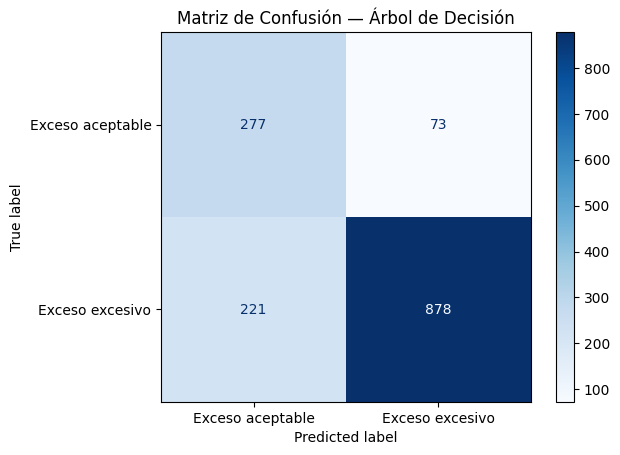

In [79]:
# ── 1. MATRIZ DE CONFUSIÓN ──────────────────────────────────────────────────
confusion_Mat = confusion_matrix(y_clasif_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_Mat,
                               display_labels=['Exceso aceptable', 'Exceso excesivo'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión — Árbol de Decisión')
plt.show()


In [80]:
# ── 2. MÉTRICAS ─────────────────────────────────────────────────────────────
accuracy  = accuracy_score(y_clasif_test, y_pred)
precision = precision_score(y_clasif_test, y_pred)
recall    = recall_score(y_clasif_test, y_pred)
f1        = f1_score(y_clasif_test, y_pred)

print(f'Accuracy:  {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1-Score:  {f1:.4f}')

Accuracy:  0.7971
Precision: 0.9232
Recall:    0.7989
F1-Score:  0.8566


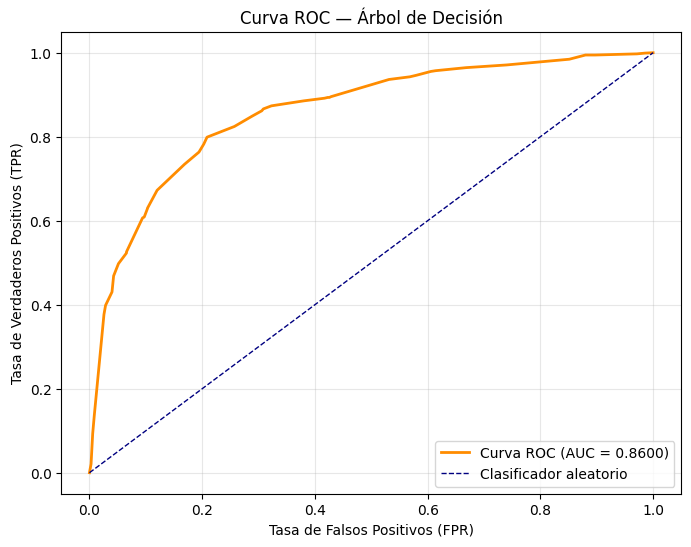

AUC: 0.8600


In [81]:
# ── 3. CURVA ROC Y AUC ──────────────────────────────────────────────────────
# Se necesitan las probabilidades (no las clases predichas)
y_clasif_prob = best_tree2.predict_proba(X_clasif_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_clasif_test, y_clasif_prob)
auc_score = roc_auc_score(y_clasif_test, y_clasif_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'Curva ROC (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--',
         label='Clasificador aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC — Árbol de Decisión')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

print(f'AUC: {auc_score:.4f}')

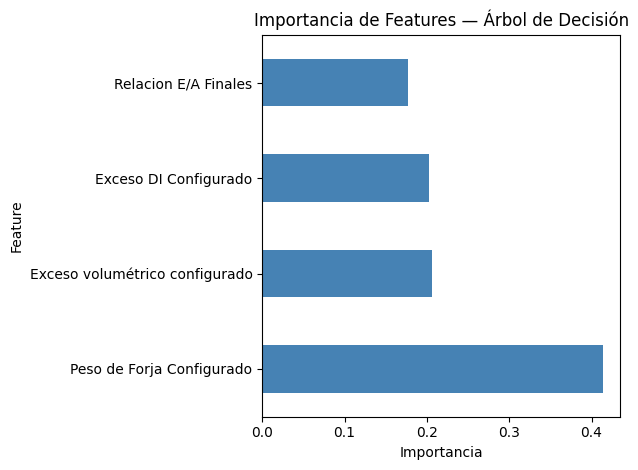

In [82]:
importancias = pd.DataFrame({
    'Feature':     selected_features3,
    'Importancia': best_tree2.feature_importances_
}).sort_values('Importancia', ascending=False)

importancias.plot(kind='barh', x='Feature', y='Importancia',
                  legend=False, color='steelblue')
plt.title('Importancia de Features — Árbol de Decisión')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

In [83]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
importancias_cv = []

for train_idx, _ in cv.split(X_clasif_train, y_clasif_train):
    arbol_cv = DecisionTreeClassifier(**grid2.best_params_,
                                       class_weight='balanced',
                                       random_state=42)
    arbol_cv.fit(X_clasif_train.iloc[train_idx],
                 y_clasif_train.iloc[train_idx])
    importancias_cv.append(arbol_cv.feature_importances_)

importancias_cv = np.array(importancias_cv)

tabla_importancia = pd.DataFrame({
    'Variable':              selected_features3,
    'Importancia media':     importancias_cv.mean(axis=0),
    'Desv. estándar (CV)':  importancias_cv.std(axis=0),
    'IC 95% inferior':      importancias_cv.mean(axis=0) - 1.96 * importancias_cv.std(axis=0),
    'IC 95% superior':      importancias_cv.mean(axis=0) + 1.96 * importancias_cv.std(axis=0),
}).sort_values('Importancia media', ascending=False)

print(tabla_importancia.to_string(index=False))

                      Variable  Importancia media  Desv. estándar (CV)  IC 95% inferior  IC 95% superior
     Peso de Forja Configurado           0.407635             0.014658         0.378906         0.436364
         Exceso DI Configurado           0.245021             0.011105         0.223256         0.266787
Exceso volumétrico configurado           0.179953             0.025971         0.129050         0.230856
          Relacion E/A Finales           0.167390             0.028144         0.112229         0.222552


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names


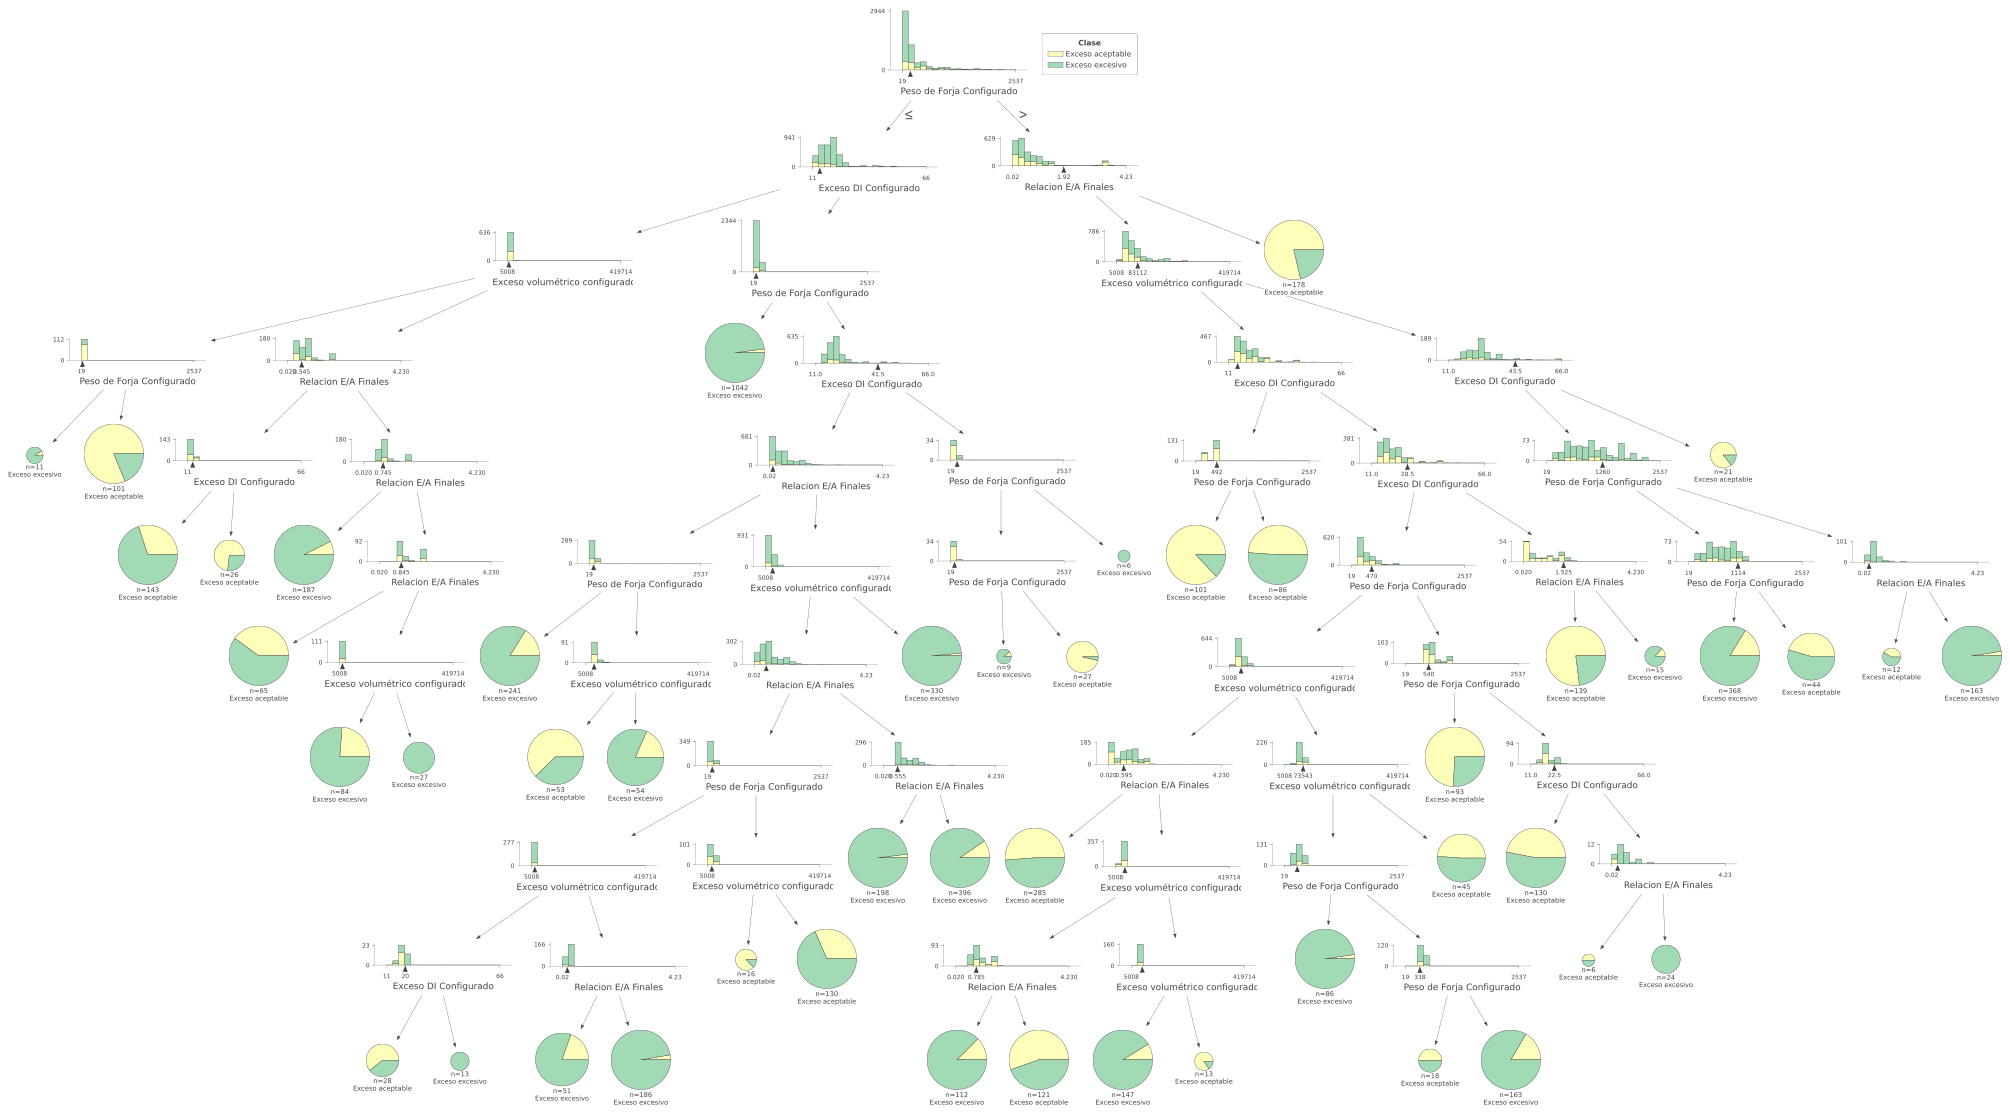

In [84]:
viz = model(best_tree2, X_clasif_train, y_clasif_train,
            target_name= 'Clase',
                feature_names=X_clasif_train.columns,
                 class_names=['Exceso aceptable', 'Exceso excesivo'])

viz.view()

# Arbol 3

In [85]:
X_clasif = df_modelo[ selected_features3]
y_clasif = df_modelo['Clase']

X_clasif_train, X_clasif_test, y_clasif_train, y_clasif_test = train_test_split(X_clasif, y_clasif, stratify= y_clasif, test_size= 0.2, random_state = 42)


tree = DecisionTreeClassifier(
    class_weight='balanced'
)

# 3. Usar GridSearchCV optimizando f1
grid3 = GridSearchCV(
    tree,
    param_grid={
        'criterion': ['entropy', 'gini'],
        'max_depth': [5, 6, 7, 8],
        'min_samples_leaf': [5, 7, 9, 11],
        'min_impurity_decrease': [0.0005, 0.0006, 0.0008, 0.0009, 0.001, 0.005]  # explorar valores suaves
    },
    scoring='f1',
    cv=5
)
grid3.fit(X_clasif_train, y_clasif_train)
best_tree3 = grid3.best_estimator_

y_clasid_pred = best_tree3.predict(X_clasif_test)
y_clasif_prob = best_tree3.predict_proba(X_clasif_test)[:, 1]

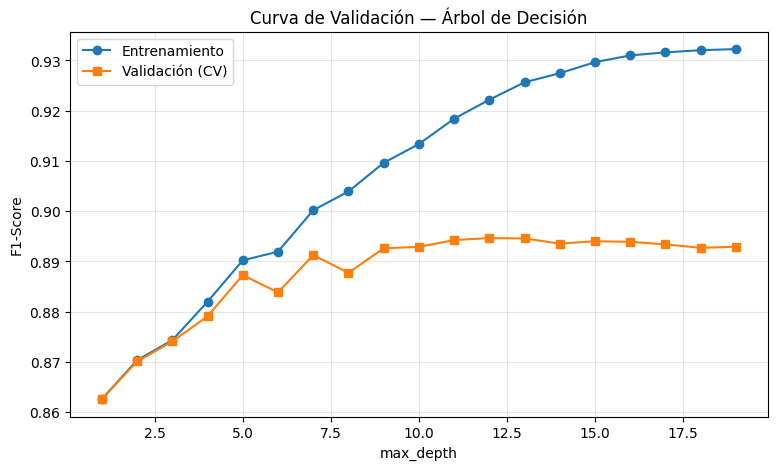

In [86]:
depths = range(1, 20)
train_scores, val_scores = validation_curve(
    DecisionTreeClassifier(criterion='entropy', random_state=42),
    X_clasif_train, y_clasif_train,
    param_name='max_depth', param_range=depths,
    cv=5, scoring='f1'
)

plt.figure(figsize=(9, 5))
plt.plot(depths, train_scores.mean(axis=1), label='Entrenamiento', marker='o')
plt.plot(depths, val_scores.mean(axis=1),   label='Validación (CV)', marker='s')
plt.xlabel('max_depth')
plt.ylabel('F1-Score')
plt.title('Curva de Validación — Árbol de Decisión')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [87]:

# Mejor combinación de hiperparámetros
print(grid3.best_params_)

# Mejor score (recall) obtenido en CV
print(grid3.best_score_)

# El mejor modelo ya listo para usar
best_tree3 = grid3.best_estimator_

# Tabla completa con todos los resultados
resultados = pd.DataFrame(grid3.cv_results_)
print(resultados[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
      .sort_values('rank_test_score'))

# Predicciones con el mejor modelo
y_pred = best_tree3.predict(X_clasif_test)

# Métricas finales
print(f"Recall:    {recall_score(y_clasif_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_clasif_test, y_pred):.4f}")
print(f"F1:        {f1_score(y_clasif_test, y_pred):.4f}")

{'criterion': 'entropy', 'max_depth': 8, 'min_impurity_decrease': 0.0005, 'min_samples_leaf': 5}
0.8267617799408591
                                                params  mean_test_score  \
72   {'criterion': 'entropy', 'max_depth': 8, 'min_...         0.826762   
48   {'criterion': 'entropy', 'max_depth': 7, 'min_...         0.826742   
52   {'criterion': 'entropy', 'max_depth': 7, 'min_...         0.826365   
49   {'criterion': 'entropy', 'max_depth': 7, 'min_...         0.825822   
50   {'criterion': 'entropy', 'max_depth': 7, 'min_...         0.825502   
..                                                 ...              ...   
115  {'criterion': 'gini', 'max_depth': 5, 'min_imp...         0.782475   
103  {'criterion': 'gini', 'max_depth': 5, 'min_imp...         0.782475   
99   {'criterion': 'gini', 'max_depth': 5, 'min_imp...         0.782475   
107  {'criterion': 'gini', 'max_depth': 5, 'min_imp...         0.782475   
111  {'criterion': 'gini', 'max_depth': 5, 'min_imp...     

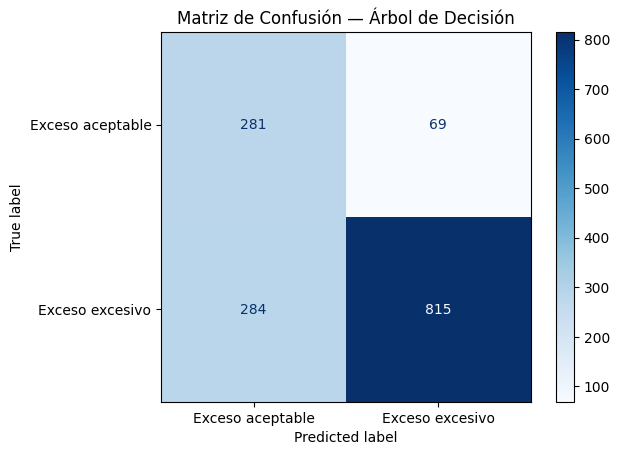

In [88]:
# ── 1. MATRIZ DE CONFUSIÓN ──────────────────────────────────────────────────
confusion_Mat = confusion_matrix(y_clasif_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_Mat,
                               display_labels=['Exceso aceptable', 'Exceso excesivo'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión — Árbol de Decisión')
plt.show()


In [89]:
# ── 2. MÉTRICAS ─────────────────────────────────────────────────────────────
accuracy  = accuracy_score(y_clasif_test, y_pred)
precision = precision_score(y_clasif_test, y_pred)
recall    = recall_score(y_clasif_test, y_pred)
f1        = f1_score(y_clasif_test, y_pred)

print(f'Accuracy:  {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1-Score:  {f1:.4f}')

Accuracy:  0.7564
Precision: 0.9219
Recall:    0.7416
F1-Score:  0.8220


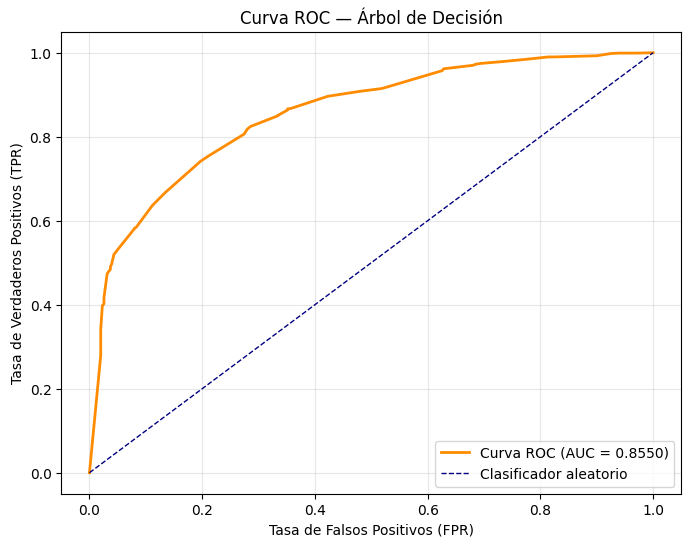

AUC: 0.8550


In [90]:
# ── 3. CURVA ROC Y AUC ──────────────────────────────────────────────────────
# Se necesitan las probabilidades (no las clases predichas)
y_clasif_prob = best_tree3.predict_proba(X_clasif_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_clasif_test, y_clasif_prob)
auc_score = roc_auc_score(y_clasif_test, y_clasif_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'Curva ROC (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--',
         label='Clasificador aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC — Árbol de Decisión')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

print(f'AUC: {auc_score:.4f}')

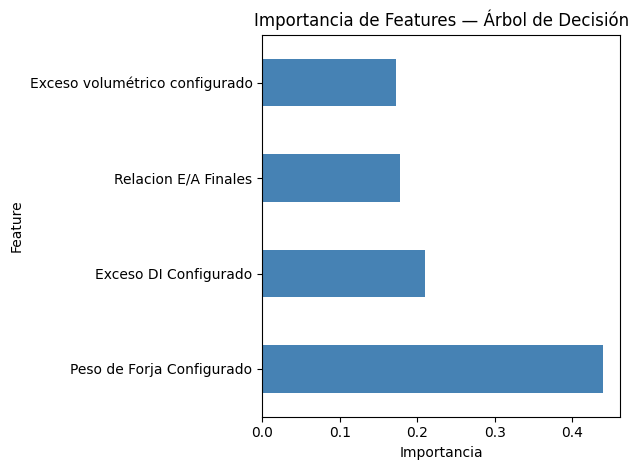

In [91]:
importancias = pd.DataFrame({
    'Feature':     selected_features3,
    'Importancia': best_tree3.feature_importances_
}).sort_values('Importancia', ascending=False)

importancias.plot(kind='barh', x='Feature', y='Importancia',
                  legend=False, color='steelblue')
plt.title('Importancia de Features — Árbol de Decisión')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

In [92]:

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
importancias_cv = []

for train_idx, _ in cv.split(X_clasif_train, y_clasif_train):
    arbol_cv = DecisionTreeClassifier(**grid3.best_params_,
                                       class_weight='balanced',
                                       random_state=42)
    arbol_cv.fit(X_clasif_train.iloc[train_idx],
                 y_clasif_train.iloc[train_idx])
    importancias_cv.append(arbol_cv.feature_importances_)

importancias_cv = np.array(importancias_cv)

tabla_importancia = pd.DataFrame({
    'Variable':              selected_features3,
    'Importancia media':     importancias_cv.mean(axis=0),
    'Desv. estándar (CV)':  importancias_cv.std(axis=0),
    'IC 95% inferior':      importancias_cv.mean(axis=0) - 1.96 * importancias_cv.std(axis=0),
    'IC 95% superior':      importancias_cv.mean(axis=0) + 1.96 * importancias_cv.std(axis=0),
}).sort_values('Importancia media', ascending=False)

print(tabla_importancia.to_string(index=False))

                      Variable  Importancia media  Desv. estándar (CV)  IC 95% inferior  IC 95% superior
     Peso de Forja Configurado           0.433958             0.022126         0.390591         0.477324
         Exceso DI Configurado           0.218352             0.010440         0.197889         0.238815
          Relacion E/A Finales           0.174104             0.023031         0.128963         0.219245
Exceso volumétrico configurado           0.173586             0.025481         0.123644         0.223529


In [93]:
viz = model(best_tree3, X_clasif_train, y_clasif_train,
            target_name= 'Clase',
                feature_names=X_clasif_train.columns,
                 class_names=['Exceso aceptable', 'Exceso excesivo'])

viz.view()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names


#Voting

In [94]:
ensemble = VotingClassifier(
    estimators=[
        ('t1', grid1.best_estimator_),
        ('t2', grid2.best_estimator_),
        ('t3', grid3.best_estimator_)
    ],
    voting='soft'
)
ensemble.fit(X_clasif_train, y_clasif_train)
y_pred_ens = ensemble.predict(X_clasif_test)
y_prob_ens  = ensemble.predict_proba(X_clasif_test)[:, 1]

In [95]:
# ── 2. MÉTRICAS ─────────────────────────────────────────────────────────────
accuracy  = accuracy_score(y_clasif_test, y_pred_ens)
precision = precision_score(y_clasif_test, y_pred_ens)
recall    = recall_score(y_clasif_test, y_pred_ens)
f1        = f1_score(y_clasif_test, y_pred_ens)

print(f'Accuracy:  {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1-Score:  {f1:.4f}')

Accuracy:  0.7964
Precision: 0.9214
Recall:    0.7998
F1-Score:  0.8563


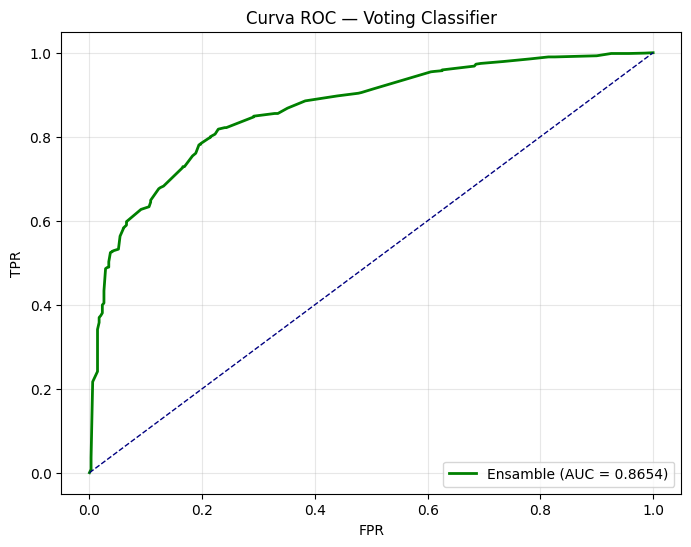

In [96]:
fpr_ens, tpr_ens, _ = roc_curve(y_clasif_test, y_prob_ens)
auc_ens = roc_auc_score(y_clasif_test, y_prob_ens)

plt.figure(figsize=(8, 6))
plt.plot(fpr_ens, tpr_ens, color='green', lw=2,
         label=f'Ensamble (AUC = {auc_ens:.4f})')
plt.plot([0, 1], [0, 1], 'navy', lw=1, linestyle='--')
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('Curva ROC — Voting Classifier')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:33:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.



Mejores parámetros XGBoost: {'learning_rate': 0.1, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 200, 'subsample': 1.0}
Mejor F1 en CV: 0.8694


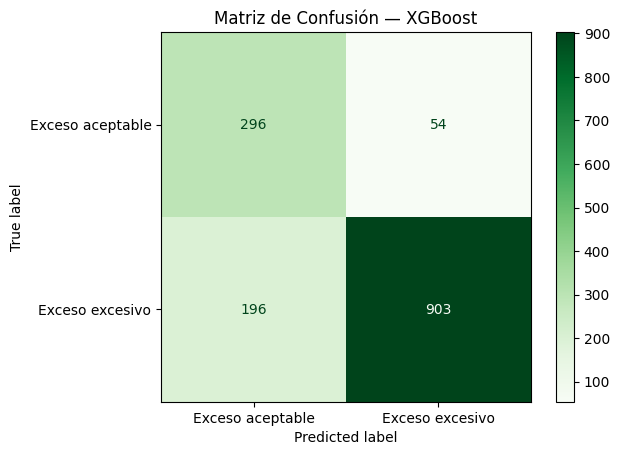

Accuracy:  0.8275
Precision: 0.9436
Recall:    0.8217
F1-Score:  0.8784


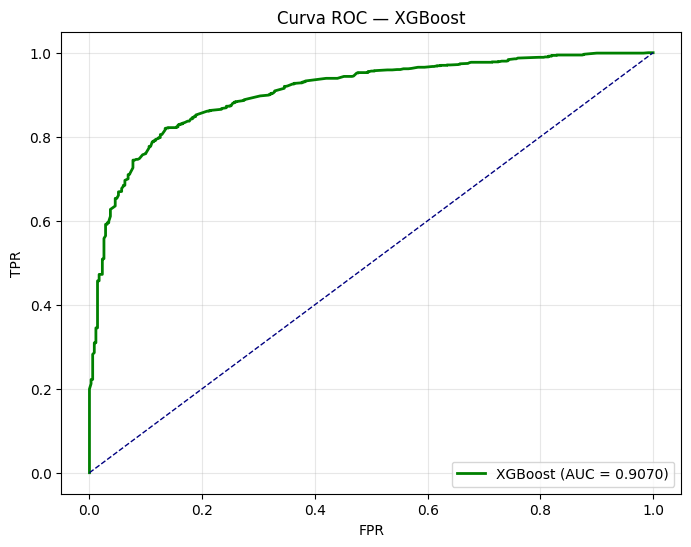

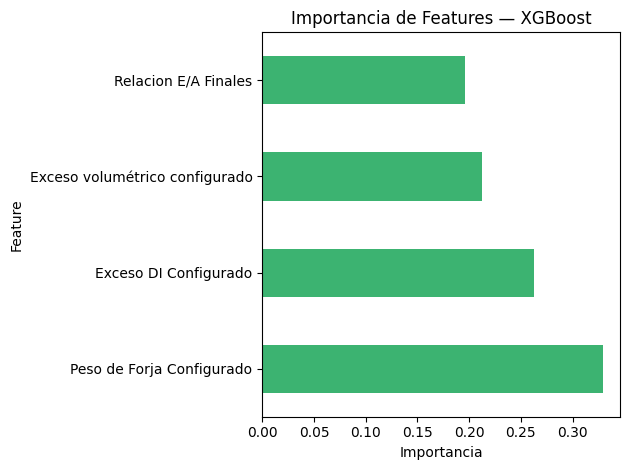

In [97]:

# ── 1. BALANCE DE CLASES ────────────────────────────────────────────────────
# XGBoost no tiene class_weight='balanced', usa scale_pos_weight
neg = (y_clasif_train == 0).sum()
pos = (y_clasif_train == 1).sum()
scale = neg / pos  # equivalente a class_weight='balanced'

# ── 2. GRID SEARCH ──────────────────────────────────────────────────────────
xgb = XGBClassifier(
    scale_pos_weight=scale,
    eval_metric='logloss',
    random_state=42,
    use_label_encoder=False
)

grid_xgb = GridSearchCV(
    xgb,
    param_grid={
        'max_depth':        [3, 5, 7],
        'n_estimators':     [50, 100, 200],
        'learning_rate':    [0.01, 0.05, 0.1],
        'min_child_weight': [1, 5, 10],   # análogo a min_samples_leaf
        'subsample':        [0.8, 1.0],
    },
    scoring='f1',
    cv=5,
    n_jobs=-1
)
grid_xgb.fit(X_clasif_train, y_clasif_train)
best_xgb = grid_xgb.best_estimator_

print("Mejores parámetros XGBoost:", grid_xgb.best_params_)
print(f"Mejor F1 en CV: {grid_xgb.best_score_:.4f}")

# ── 3. PREDICCIONES ─────────────────────────────────────────────────────────
y_pred_xgb  = best_xgb.predict(X_clasif_test)
y_prob_xgb  = best_xgb.predict_proba(X_clasif_test)[:, 1]

# ── 4. MATRIZ DE CONFUSIÓN ──────────────────────────────────────────────────
disp = ConfusionMatrixDisplay(
    confusion_matrix(y_clasif_test, y_pred_xgb),
    display_labels=['Exceso aceptable', 'Exceso excesivo']
)
disp.plot(cmap='Greens')
plt.title('Matriz de Confusión — XGBoost')
plt.show()

# ── 5. MÉTRICAS ─────────────────────────────────────────────────────────────
print(f"Accuracy:  {accuracy_score(y_clasif_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_clasif_test, y_pred_xgb):.4f}")
print(f"Recall:    {recall_score(y_clasif_test, y_pred_xgb):.4f}")
print(f"F1-Score:  {f1_score(y_clasif_test, y_pred_xgb):.4f}")

# ── 6. CURVA ROC ────────────────────────────────────────────────────────────
fpr_xgb, tpr_xgb, _ = roc_curve(y_clasif_test, y_prob_xgb)
auc_xgb = roc_auc_score(y_clasif_test, y_prob_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, color='green', lw=2,
         label=f'XGBoost (AUC = {auc_xgb:.4f})')
plt.plot([0, 1], [0, 1], 'navy', lw=1, linestyle='--')
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('Curva ROC — XGBoost')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# ── 7. IMPORTANCIA DE FEATURES ──────────────────────────────────────────────
pd.DataFrame({
    'Feature':     selected_features3,
    'Importancia': best_xgb.feature_importances_
}).sort_values('Importancia', ascending=False).plot(
    kind='barh', x='Feature', y='Importancia',
    legend=False, color='mediumseagreen'
)
plt.title('Importancia de Features — XGBoost')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

# Tabla Comparativa de modelos

In [98]:
resultados_cv = cross_validate(
    best_tree1,
    X_clasif, y_clasif,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
    return_train_score=True
)

tabla_cv = pd.DataFrame({
    'Métrica':    ['Accuracy', 'Precisión', 'Recall', 'F1', 'AUC'],
    'Media CV':   [resultados_cv[f'test_{m}'].mean()
                   for m in ['accuracy','precision','recall','f1','roc_auc']],
    'Desv. Est.': [resultados_cv[f'test_{m}'].std()
                   for m in ['accuracy','precision','recall','f1','roc_auc']],
})
print(tabla_cv.to_string(index=False))

  Métrica  Media CV  Desv. Est.
 Accuracy  0.756868    0.019314
Precisión  0.916109    0.004588
   Recall  0.748041    0.030875
       F1  0.823182    0.017436
      AUC  0.846988    0.008404


In [99]:
resultados_cv = cross_validate(
    best_tree2,
    X_clasif, y_clasif,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
    return_train_score=True
)

tabla_cv = pd.DataFrame({
    'Métrica':    ['Accuracy', 'Precisión', 'Recall', 'F1', 'AUC'],
    'Media CV':   [resultados_cv[f'test_{m}'].mean()
                   for m in ['accuracy','precision','recall','f1','roc_auc']],
    'Desv. Est.': [resultados_cv[f'test_{m}'].std()
                   for m in ['accuracy','precision','recall','f1','roc_auc']],
})
print(tabla_cv.to_string(index=False))

  Métrica  Media CV  Desv. Est.
 Accuracy  0.783101    0.009315
Precisión  0.917914    0.007090
   Recall  0.784271    0.016657
       F1  0.845697    0.008252
      AUC  0.852767    0.006485


In [100]:

resultados_cv = cross_validate(
    best_tree3,
    X_clasif, y_clasif,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
    return_train_score=True
)

tabla_cv = pd.DataFrame({
    'Métrica':    ['Accuracy', 'Precisión', 'Recall', 'F1', 'AUC'],
    'Media CV':   [resultados_cv[f'test_{m}'].mean()
                   for m in ['accuracy','precision','recall','f1','roc_auc']],
    'Desv. Est.': [resultados_cv[f'test_{m}'].std()
                   for m in ['accuracy','precision','recall','f1','roc_auc']],
})
print(tabla_cv.to_string(index=False))

  Métrica  Media CV  Desv. Est.
 Accuracy  0.756868    0.019314
Precisión  0.916109    0.004588
   Recall  0.748041    0.030875
       F1  0.823182    0.017436
      AUC  0.847233    0.008526


In [101]:
# Definir métricas de lineal 1 según outputs anteriores
r2_lineal1 = 0.9760
rmse_lineal1 = 7725.9207
mae_lineal1 = 4650.8770

# Definir métricas de ridge 1 según outputs anteriores
r2_ridge1 = 0.9760
rmse_ridge1 = 7725.9979

mae_ridge1 = mean_absolute_error(y_Original_test, y_Original_pred_ridge)

# Definir métricas de lineal 2 según outputs anteriores

r2_lineal2 = r2
rmse_lineal2 = rmse
mae_lineal2 = mae
recall = recall_score(y_clasif_test, y_pred)
f1     = f1_score(y_clasif_test, y_pred)
# auc_score, f1, y recall ya definidos para 'Árbol Clasificación'

resumen = pd.DataFrame({
    'Modelo': ['Lineal 1', 'Ridge 1', 'Lineal 2 (Box-Cox)', 'Árbol Clasificación'],
    'Tipo': ['Regresión', 'Regresión', 'Regresión', 'Clasificación'],
    'R² / AUC': [r2_lineal1, r2_ridge1, r2_lineal2, auc_score],
    'RMSE / F1': [rmse_lineal1, rmse_ridge1, rmse_lineal2, f1],
    'MAE / Recall': [mae_lineal1, mae_ridge1, mae_lineal2, recall]
})
print(resumen.to_string(index=False))

             Modelo          Tipo  R² / AUC   RMSE / F1  MAE / Recall
           Lineal 1     Regresión  0.976000 7725.920700   4650.877000
            Ridge 1     Regresión  0.976000 7725.997900   4651.020068
 Lineal 2 (Box-Cox)     Regresión  0.970665 8547.922654   5020.659612
Árbol Clasificación Clasificación  0.855044    0.821987      0.741583


In [102]:
def calcular_ahorro_potencial(modelo, X_test, df_original, reduccion=0.10):
    """
    Calcula el volumen total ahorrado si a todas las piezas que el modelo
    predice como 'exceso excesivo' se les reduce un porcentaje del exceso
    volumétrico configurado.

    Parámetros:
    -----------
    modelo      : modelo entrenado (best_tree, ensemble, best_xgb, etc.)
    X_test      : features del conjunto de prueba (DataFrame)
    df_original : df_modelo completo, para recuperar el exceso volumétrico
    reduccion   : fracción a reducir del exceso configurado (default: 10%)

    Retorna:
    --------
    dict con métricas de ahorro
    """
    # Predicciones
    y_pred_local = modelo.predict(X_test)

    # Recuperar índices de las piezas marcadas como excedidas en el test set
    idx_test        = X_test.index
    idx_excedidas   = idx_test[y_pred_local == 1]
    idx_aceptables  = idx_test[y_pred_local == 0]

    # Exceso volumétrico configurado de esas piezas
    vol_excedidas  = df_original.loc[idx_excedidas,  'Exceso volumétrico configurado']
    vol_aceptables = df_original.loc[idx_aceptables, 'Exceso volumétrico configurado']
    vol_total      = df_original.loc[idx_test,        'Exceso volumétrico configurado']

    # Ahorro: 10% del exceso configurado de cada pieza marcada
    ahorro_por_pieza = vol_excedidas * reduccion
    ahorro_total     = ahorro_por_pieza.sum()

    # Reporte
    print("=" * 52)
    print(f"  ANÁLISIS DE AHORRO POTENCIAL ({reduccion*100:.0f}% de reducción)")
    print("=" * 52)
    print(f"  Piezas en test set            : {len(idx_test)}")
    print(f"  Piezas marcadas como excedidas: {y_pred_local.sum()}")
    print(f"  Piezas no intervenidas        : {(y_pred_local==0).sum()}")
    print("-" * 52)
    print(f"  Exceso vol. total (test)      : {vol_total.sum():>10.2f} cm³")
    print(f"  Exceso vol. piezas marcadas   : {vol_excedidas.sum():>10.2f} cm³")
    print(f"  Ahorro estimado ({reduccion*100:.0f}%)          : {ahorro_total:>10.2f} cm³")
    print(f"  Ahorro promedio por pieza     : {ahorro_por_pieza.mean():>10.2f} cm³")
    print(f"  % del exceso total ahorrado   : {ahorro_total/vol_total.sum()*100:>9.1f}%")
    print("=" * 52)

    return {
        'piezas_marcadas':  int(y_pred_local.sum()),
        'ahorro_total_cm3': ahorro_total,
        'ahorro_promedio_cm3': ahorro_por_pieza.mean(),
        'pct_ahorro': ahorro_total / vol_total.sum() * 100
    }

# ── USO ─────────────────────────────────────────────────────────────────────
ahorro_arbol    = calcular_ahorro_potencial(grid1.best_estimator_, X_clasif_test, df_modelo)
ahorro_ensemble = calcular_ahorro_potencial(ensemble,              X_clasif_test, df_modelo)
ahorro_xgb      = calcular_ahorro_potencial(best_xgb,             X_clasif_test, df_modelo)

  ANÁLISIS DE AHORRO POTENCIAL (10% de reducción)
  Piezas en test set            : 1449
  Piezas marcadas como excedidas: 884
  Piezas no intervenidas        : 565
----------------------------------------------------
  Exceso vol. total (test)      : 67053704.93 cm³
  Exceso vol. piezas marcadas   : 37504881.41 cm³
  Ahorro estimado (10%)          : 3750488.14 cm³
  Ahorro promedio por pieza     :    4242.63 cm³
  % del exceso total ahorrado   :       5.6%
  ANÁLISIS DE AHORRO POTENCIAL (10% de reducción)
  Piezas en test set            : 1449
  Piezas marcadas como excedidas: 954
  Piezas no intervenidas        : 495
----------------------------------------------------
  Exceso vol. total (test)      : 67053704.93 cm³
  Exceso vol. piezas marcadas   : 40667423.20 cm³
  Ahorro estimado (10%)          : 4066742.32 cm³
  Ahorro promedio por pieza     :    4262.83 cm³
  % del exceso total ahorrado   :       6.1%
  ANÁLISIS DE AHORRO POTENCIAL (10% de reducción)
  Piezas en test set      

## Generar CSV

### Total de los datos

In [103]:
# Diccionario de densidades (g/cm³)
DENSIDADES_MATERIALES = {
    # Aceros al Carbono
    '1008': 7.85, '1018': 7.85, '1020': 7.85, '1030': 7.85, '1035': 7.85,
    '1040M': 7.85, '1045': 7.85, '1070M': 7.85, '1552': 7.85,

    # Aceros Aleados
    '4120M': 7.85, '4120M CAT': 7.85, '4122M': 7.85, '4130': 7.85,
    '4130 FM': 7.85, '4130 TSP': 7.85, '4140': 7.85, '4140 FM O&G': 7.85,
    '4150': 7.85, '4320': 7.85, '4330V': 7.85, '4330V-DQ': 7.85,
    '4330 Modified  PS': 7.85, '4340': 7.85, '4340 BS': 7.85, '4340 FM': 7.85,
    '4340 VAR': 7.85, '4340 VAR PW': 7.85, '8620H': 7.85, '8630M': 7.85,
    '8630M4': 7.85, '8630M5': 7.85, '105': 7.85, '105M2': 7.85,
    '105 (CE 0.42)': 7.85, '105HF': 7.85, '42CrMo4': 7.85,
    '18CRNIMO7-6 REV 2': 7.85, '3311 T': 7.85, 'B50A368E1': 7.85,
    'CRMOV': 7.85, 'NiCrMoV GE': 7.85, 'EN355B': 7.85,
    'A588-Grade B/A871- Type II (Sabre Industries)': 7.85, 'A871 TYPE 1': 7.85,

    # Aceros Inoxidables
    '304L': 7.93, '310': 7.93, '316L': 7.98, '316/316H': 7.98,
    '321/321H': 7.98, '321/321H (FRIMP 1)': 7.98, '347/347H': 7.98,
    '410S': 7.75, '410S VOD FM': 7.75, '416 ALRO': 7.75, '431S': 7.75,
    '17-4 PH': 7.80, '174PH': 7.80,

    # Aceros Herramienta
    'D2': 7.70, 'H13 SA': 7.80,

    # Aceros para alta/baja temperatura
    'F5': 7.85, 'F9': 7.85, 'F11M2': 7.85, 'F22MF': 7.85, 'F22 SFC1-2': 7.85,
    'F51': 7.80, 'F70': 7.85, 'F91': 7.85, 'F91 FM FOX': 7.85, 'A182 F6NM': 7.85,
    'LF2H': 7.85, 'LF2L': 7.85, 'LF6': 7.85, 'LF6M': 7.85,

    # Aluminios
    'Al 6061': 2.70, 'Al 7050': 2.80, 'Al 2219 (FRIMP1)': 2.84,

    # Aleaciones especiales
    # Aleaciones especiales
    'Nitronic 60    SS': 7.93,
}

# Diccionario de precios (MXN por kg)
PRECIOS_MATERIALES_MXN = {
    # Aceros al Carbono ($30-36/kg)
    '1008': 30.0, '1018': 32.0, '1020': 32.0, '1030': 33.0, '1035': 33.0,
    '1040M': 34.0, '1045': 35.0, '1070M': 36.0, '1552': 35.0,

    # Aceros Aleados ($38-55/kg)
    '4120M': 40.0, '4120M CAT': 40.0, '4122M': 40.0, '4130': 40.0,
    '4130 FM': 42.0, '4130 TSP': 42.0, '4140': 42.0, '4140 FM O&G': 45.0,
    '4150': 43.0, '4320': 41.0, '4330V': 48.0, '4330V-DQ': 50.0,
    '4330 Modified  PS': 50.0, '4340': 45.0, '4340 BS': 45.0, '4340 FM': 48.0,
    '4340 VAR': 55.0, '4340 VAR PW': 55.0, '8620H': 40.0, '8630M': 40.0,
    '8630M4': 40.0, '8630M5': 40.0, '105': 43.0, '105M2': 43.0,
    '105 (CE 0.42)': 43.0, '105HF': 45.0, '42CrMo4': 42.0,
    '18CRNIMO7-6 REV 2': 48.0, '3311 T': 45.0, 'B50A368E1': 42.0,
    'CRMOV': 45.0, 'NiCrMoV GE': 52.0, 'EN355B': 45.0,
    'A588-Grade B/A871- Type II (Sabre Industries)': 40.0, 'A871 TYPE 1': 40.0,

    # Aceros Inoxidables ($65-120/kg)
    '304L': 85.0, '310': 110.0, '316L': 95.0, '316/316H': 95.0,
    '321/321H': 90.0, '321/321H (FRIMP 1)': 90.0, '347/347H': 92.0,
    '410S': 65.0, '410S VOD FM': 70.0, '416 ALRO': 68.0, '431S': 70.0,
    '17-4 PH': 115.0, '174PH': 115.0,

    # Aceros Herramienta ($95-120/kg)
    'D2': 95.0, 'H13 SA': 100.0,

    # Aceros especiales ($48-85/kg)
    'F5': 50.0, 'F9': 52.0, 'F11M2': 53.0, 'F22MF': 54.0, 'F22 SFC1-2': 54.0,
    'F51': 85.0, 'F70': 55.0, 'F91': 60.0, 'F91 FM FOX': 62.0, 'A182 F6NM': 80.0,
    'LF2H': 50.0, 'LF2L': 48.0, 'LF6': 52.0, 'LF6M': 53.0,

    # Aluminios ($85-140/kg)
    'Al 6061': 90.0, 'Al 7050': 130.0, 'Al 2219 (FRIMP1)': 110.0,

    # Aleaciones especiales
    'Nitronic 60    SS': 140.0,
}

In [104]:
def clasificar_material(material):
    """Clasifica material en 5 categorías principales"""
    if pd.isna(material):
        return 'Sin Clasificar'

    material_str = str(material).strip()

    if material_str.startswith('Al '):
        return 'Aluminio'
    elif any(x in material_str for x in ['304', '316', '321', '347', '310',
                                          '410', '416', '431', '17-4', '174PH', 'Nitronic']):
        return 'Acero Inoxidable'
    elif material_str in ['D2', 'H13 SA']:
        return 'Acero Herramienta'
    elif material_str.startswith(('10', '15')):
        return 'Acero al Carbono'
    else:
        return 'Acero Aleado'

In [105]:
# Crear copia del dataset completo
df_baseline = df_modelo.copy()

# ─── AGREGAR DATOS DEL CATÁLOGO ───
df_baseline['Densidad_g_cm3'] = df_baseline['Material'].map(DENSIDADES_MATERIALES)
df_baseline['Precio_MXN_kg'] = df_baseline['Material'].map(PRECIOS_MATERIALES_MXN)

# Valores por defecto para materiales no catalogados
df_baseline['Densidad_g_cm3'].fillna(7.85, inplace=True)
df_baseline['Precio_MXN_kg'].fillna(40.00, inplace=True)

# ─── CLASIFICAR MATERIALES ───
df_baseline['Categoria_Material'] = df_baseline['Material'].apply(clasificar_material)

print(f"✅ Dataset completo preparado: {len(df_baseline):,} piezas")

✅ Dataset completo preparado: 7,243 piezas


/tmp/ipykernel_3965/1786455987.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


/tmp/ipykernel_3965/1786455987.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or d

In [106]:
# Calcular PESO del exceso volumétrico
df_baseline['Peso_Exceso_kg'] = (
    df_baseline['Exceso volumétrico configurado'] *
    df_baseline['Densidad_g_cm3'] / 1000
)

# Calcular COSTO del exceso volumétrico
df_baseline['Costo_Exceso_MXN'] = (
    df_baseline['Peso_Exceso_kg'] *
    df_baseline['Precio_MXN_kg']
)

print("✅ Peso y costo calculados")
print(f"   Peso total del exceso: {df_baseline['Peso_Exceso_kg'].sum():,.2f} kg")
print(f"   Costo total del exceso: ${df_baseline['Costo_Exceso_MXN'].sum():,.2f} MXN")

✅ Peso y costo calculados
   Peso total del exceso: 2,458,126.90 kg
   Costo total del exceso: $123,828,196.11 MXN


In [107]:
# Seleccionar columnas relevantes para Power BI
columnas_baseline = [
    'Familia geométrica',
    'Material',
    'Categoria_Material',
    'Clase',  # Clase REAL (0=Aceptable, 1=Excedida)
    'Exceso volumétrico configurado',
    'Densidad_g_cm3',
    'Precio_MXN_kg',
    'Peso_Exceso_kg',
    'Costo_Exceso_MXN',
    'Calidad'
]

# Crear DataFrame final
df_export_baseline = df_baseline[columnas_baseline].copy()

# Renombrar para claridad
df_export_baseline = df_export_baseline.rename(columns={
    'Familia geométrica': 'Familia_Geometrica',
    'Exceso volumétrico configurado': 'Exceso_Volumen_cm3',
    'Clase': 'Clase_Real'
})

# Exportar
df_export_baseline.to_csv('modelo1_situacion_actual_completa.csv', index=False, encoding='utf-8-sig')

print(f"\n✅ CSV exportado: modelo1_situacion_actual_completa.csv")
print(f"   Total de filas: {len(df_export_baseline):,}")
print(f"   Total de columnas: {len(df_export_baseline.columns)}")


✅ CSV exportado: modelo1_situacion_actual_completa.csv
   Total de filas: 7,243
   Total de columnas: 10


In [108]:
print("\n" + "="*80)
print("  📊 RESUMEN POR CATEGORÍA DE MATERIAL")
print("="*80)

resumen_categoria = df_baseline.groupby('Categoria_Material').agg({
    'Costo_Exceso_MXN': 'sum',
    'Peso_Exceso_kg': 'sum',
    'Exceso volumétrico configurado': 'sum',
    'Familia geométrica': 'count'
}).round(2)

resumen_categoria.columns = ['Costo_Total_MXN', 'Peso_Total_kg', 'Volumen_Total_cm3', 'Num_Piezas']
resumen_categoria = resumen_categoria.sort_values('Costo_Total_MXN', ascending=False)

# Agregar porcentajes
resumen_categoria['%_Costo'] = (
    resumen_categoria['Costo_Total_MXN'] /
    resumen_categoria['Costo_Total_MXN'].sum() * 100
).round(1)

print(resumen_categoria.to_string())
print("="*80)


  📊 RESUMEN POR CATEGORÍA DE MATERIAL
                    Costo_Total_MXN  Peso_Total_kg  Volumen_Total_cm3  Num_Piezas  %_Costo
Categoria_Material                                                                        
Acero Aleado            55564555.75     1180036.10       1.503262e+08        2929     44.9
Acero al Carbono        35655656.96      883594.97       1.125599e+08        2377     28.8
Acero Inoxidable        24465382.53      305036.16       3.883196e+07        1193     19.8
Aluminio                 6912614.99       76523.87       2.832715e+07         677      5.6
Acero Herramienta        1229985.88       12935.80       1.679613e+06          67      1.0


In [109]:
print("\n" + "="*80)
print("  📊 RESUMEN EJECUTIVO - SITUACIÓN ACTUAL COMPLETA")
print("="*80)
print(f"  Total de piezas: {len(df_baseline):,}")
print(f"  Piezas con exceso (Clase=1): {df_baseline['Clase'].sum():,} ({df_baseline['Clase'].sum()/len(df_baseline)*100:.1f}%)")
print(f"  Piezas aceptables (Clase=0): {(df_baseline['Clase']==0).sum():,} ({(df_baseline['Clase']==0).sum()/len(df_baseline)*100:.1f}%)")
print("-"*80)
print(f"  💰 COSTO TOTAL DEL DESPERDICIO:")
print(f"  ${df_baseline['Costo_Exceso_MXN'].sum():,.2f} MXN")
print(f"  (${df_baseline['Costo_Exceso_MXN'].sum()/1000000:.2f} Millones MXN)")
print("-"*80)
print(f"  ⚖️ PESO TOTAL DEL DESPERDICIO:")
print(f"  {df_baseline['Peso_Exceso_kg'].sum():,.2f} kg")
print(f"  {df_baseline['Peso_Exceso_kg'].sum()/1000:,.2f} toneladas")
print("-"*80)
print(f"  📦 VOLUMEN TOTAL DEL DESPERDICIO:")
print(f"  {df_baseline['Exceso volumétrico configurado'].sum():,.2f} cm³")
print(f"  {df_baseline['Exceso volumétrico configurado'].sum()/1000000:,.2f} m³")
print("="*80)


  📊 RESUMEN EJECUTIVO - SITUACIÓN ACTUAL COMPLETA
  Total de piezas: 7,243
  Piezas con exceso (Clase=1): 5,493 (75.8%)
  Piezas aceptables (Clase=0): 1,750 (24.2%)
--------------------------------------------------------------------------------
  💰 COSTO TOTAL DEL DESPERDICIO:
  $123,828,196.11 MXN
  ($123.83 Millones MXN)
--------------------------------------------------------------------------------
  ⚖️ PESO TOTAL DEL DESPERDICIO:
  2,458,126.90 kg
  2,458.13 toneladas
--------------------------------------------------------------------------------
  📦 VOLUMEN TOTAL DEL DESPERDICIO:
  331,724,774.33 cm³
  331.72 m³


### Costos

In [110]:
# Hacer predicciones del modelo
y_pred = ensemble.predict(X_clasif_test)

# Crear DataFrame con los índices del test set (1,449 piezas)
df_analisis = df_modelo.loc[X_clasif_test.index].copy()

# ─── PREDICCIÓN DEL MODELO ───
df_analisis['Clase_Predicha'] = y_pred
df_analisis['Requiere_Intervencion'] = df_analisis['Clase_Predicha'].map({
    0: 'No',
    1: 'Sí'
})

# ─── DATOS DEL CATÁLOGO ───
df_analisis['Densidad_g_cm3'] = df_analisis['Material'].map(DENSIDADES_MATERIALES)
df_analisis['Precio_MXN_kg'] = df_analisis['Material'].map(PRECIOS_MATERIALES_MXN)

# Valores por defecto para materiales no catalogados
df_analisis['Densidad_g_cm3'].fillna(7.85, inplace=True)
df_analisis['Precio_MXN_kg'].fillna(40.00, inplace=True)

# ─── CATEGORÍA DE MATERIAL ───
df_analisis['Categoria_Material'] = df_analisis['Material'].apply(clasificar_material)

print(f"✅ Análisis base creado: {len(df_analisis):,} piezas")
print(f"   Piezas marcadas como excedidas: {df_analisis['Clase_Predicha'].sum():,}")

✅ Análisis base creado: 1,449 piezas
   Piezas marcadas como excedidas: 954


/tmp/ipykernel_3965/3222517055.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


/tmp/ipykernel_3965/3222517055.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or 

In [111]:
# ESCENARIO 1: Sin modelo (situación actual)
df_analisis['Exceso_Vol_SinModelo_cm3'] = df_analisis['Exceso volumétrico configurado']

df_analisis['Peso_Exceso_SinModelo_kg'] = (
    df_analisis['Exceso_Vol_SinModelo_cm3'] *
    df_analisis['Densidad_g_cm3'] / 1000
)

df_analisis['Costo_Exceso_SinModelo_MXN'] = (
    df_analisis['Peso_Exceso_SinModelo_kg'] *
    df_analisis['Precio_MXN_kg']
)

print("✅ Escenario SIN modelo calculado")
print(f"   Costo total actual: ${df_analisis['Costo_Exceso_SinModelo_MXN'].sum():,.2f} MXN")

✅ Escenario SIN modelo calculado
   Costo total actual: $25,188,934.90 MXN


In [112]:
# ESCENARIO 2: Con modelo (10% reducción en piezas excedidas)
reduccion = 0.10

df_analisis['Exceso_Vol_ConModelo_cm3'] = df_analisis.apply(
    lambda row: row['Exceso volumétrico configurado'] * (1 - reduccion)
               if row['Clase_Predicha'] == 1
               else row['Exceso volumétrico configurado'],
    axis=1
)

df_analisis['Peso_Exceso_ConModelo_kg'] = (
    df_analisis['Exceso_Vol_ConModelo_cm3'] *
    df_analisis['Densidad_g_cm3'] / 1000
)

df_analisis['Costo_Exceso_ConModelo_MXN'] = (
    df_analisis['Peso_Exceso_ConModelo_kg'] *
    df_analisis['Precio_MXN_kg']
)

print("✅ Escenario CON modelo calculado")
print(f"   Costo con reducción: ${df_analisis['Costo_Exceso_ConModelo_MXN'].sum():,.2f} MXN")

✅ Escenario CON modelo calculado
   Costo con reducción: $23,619,983.92 MXN


In [113]:
df_analisis.columns

Index(['Orden', 'N Cliente', 'Industria', 'Tipo', 'Material', 'Familia',
       'Roladora', 'DE Final', 'DI Final', 'Altura Final',
       'Exceso DE configurado', 'Exceso DI Configurado',
       'Exceso Configurado Altura', 'DE Forja Configurada',
       'DI Forja Configurada', 'Altura Forja Configurada',
       'Peso de Forja Configurado', 'DE Forja Real 1', 'DE Forja Real 2',
       'DI Forja Real 1', 'DI Forja Real 2', 'Altura Forja Real 1',
       'Altura Forja Real 2', 'Ovalamiento', 'Pandeamiento', 'Conicidad 1',
       'Conicidad 2', 'DE Exceso Real 1', 'DE Exceso Real 2',
       'DI Exceso Real 1', 'DI Exceso Real 2', 'Altura Exceso Real 1',
       'Altura Exceso Real 2', 'Peso Calculado', '% Pesos',
       'Relacion E/A Finales', 'Familia geométrica', 'Rango peso', 'Rango DE',
       'Calidad', 'Motivo', 'Planta', 'Exceso volumétrico configurado',
       'Exceso volumétrico Real', 'Exceso volumétrico config transformado',
       'Exceso volumétrico real transformado', 'Rango 

In [114]:
df_analisis[df_analisis['Familia geométrica'] == 'Arandela 4']

,Orden,N Cliente,Industria,Tipo,Material,Familia,Roladora,DE Final,DI Final,Altura Final,Exceso DE configurado,Exceso DI Configurado,Exceso Configurado Altura,DE Forja Configurada,DI Forja Configurada,Altura Forja Configurada,Peso de Forja Configurado,DE Forja Real 1,DE Forja Real 2,DI Forja Real 1,DI Forja Real 2,Altura Forja Real 1,Altura Forja Real 2,Ovalamiento,Pandeamiento,Conicidad 1,Conicidad 2,DE Exceso Real 1,DE Exceso Real 2,DI Exceso Real 1,DI Exceso Real 2,Altura Exceso Real 1,Altura Exceso Real 2,Peso Calculado,% Pesos,Relacion E/A Finales,Familia geométrica,Rango peso,Rango DE,Calidad,Motivo,Planta,Exceso volumétrico configurado,Exceso volumétrico Real,Exceso volumétrico config transformado,Exceso volumétrico real transformado,Rango DE Codificado,Ratio exceso,Ratio > 0.9,Ratio > 1,Ratio > 1.1,Ratio > 1.15,Ratio > 1.2,Ratio > 1.3,Ratio > 1.4,Ratio > 1.5,Ratio > 1.6,Ratio > 1.7,Ratio > 1.8,Ratio > 1.9,Ratio > 2,Ratio > 2.1,Ratio > 2.2,Ratio > 2.25,Clase,Clase_Predicha,Requiere_Intervencion,Densidad_g_cm3,Precio_MXN_kg,Categoria_Material,Exceso_Vol_SinModelo_cm3,Peso_Exceso_SinModelo_kg,Costo_Exceso_SinModelo_MXN,Exceso_Vol_ConModelo_cm3,Peso_Exceso_ConModelo_kg,Costo_Exceso_ConModelo_MXN
6592,835012.0,381.0,Heavy Industries,ARA,105,Aceros,R3,1321.0,624.0,57.0,28.0,32.0,28.0,1349.0,592.0,85.0,772.0,1352.0,1352.0,596.0,596.0,80.0,80.0,0.0,0.0,0.0,0.0,31.0,31.0,28.0,28.0,23.0,23.0,726.0,-5.91,4.09,Arandela 4,De 750 a 1000kg,De 1250 a 1500mm,Pieza buena,Pieza buena,Santa Catarina,149604.966943,144392.797695,1.707353,1.576064,5,0.96516,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,0,0,No,7.85,43.0,Acero al Carbono,149604.966943,1174.39899,50499.156591,149604.966943,1174.39899,50499.156591


In [115]:
# AHORRO POR PIEZA
df_analisis['Ahorro_Volumen_cm3'] = (
    df_analisis['Exceso_Vol_SinModelo_cm3'] -
    df_analisis['Exceso_Vol_ConModelo_cm3']
)

df_analisis['Ahorro_Peso_kg'] = (
    df_analisis['Peso_Exceso_SinModelo_kg'] -
    df_analisis['Peso_Exceso_ConModelo_kg']
)

df_analisis['Ahorro_Dinero_MXN'] = (
    df_analisis['Costo_Exceso_SinModelo_MXN'] -
    df_analisis['Costo_Exceso_ConModelo_MXN']
)

df_analisis['Ahorro_Porcentual'] = (
    df_analisis['Ahorro_Dinero_MXN'] /
    df_analisis['Costo_Exceso_SinModelo_MXN'] * 100
).fillna(0)

print("✅ Ahorros calculados")
print(f"   Ahorro total estimado: ${df_analisis['Ahorro_Dinero_MXN'].sum():,.2f} MXN")
print(f"   Ahorro promedio/pieza: ${df_analisis['Ahorro_Dinero_MXN'].mean():,.2f} MXN")

✅ Ahorros calculados
   Ahorro total estimado: $1,568,950.98 MXN
   Ahorro promedio/pieza: $1,082.78 MXN


In [116]:
# EXPORTAR CSV con las 1,449 piezas + todos los cálculos
df_analisis.to_csv('modelo2_testset_completo.csv', index=False, encoding='utf-8-sig')

print("\n" + "="*80)
print("  📊 RESUMEN EJECUTIVO")
print("="*80)
print(f"  Total de piezas analizadas: {len(df_analisis):,}")
print(f"  Piezas marcadas (excedidas): {df_analisis['Clase_Predicha'].sum():,} ({df_analisis['Clase_Predicha'].sum()/len(df_analisis)*100:.1f}%)")
print(f"  Piezas no intervenidas: {(df_analisis['Clase_Predicha']==0).sum():,}")
print("-"*80)
print(f"  💰 Ahorro total: ${df_analisis['Ahorro_Dinero_MXN'].sum():,.2f} MXN")
print(f"  ⚖️ Ahorro peso: {df_analisis['Ahorro_Peso_kg'].sum()/1000:,.2f} toneladas")
print("="*80)
print(f"\n✅ CSV exportado: modelo2_testset_completo.csv")
print(f"   Total de columnas: {len(df_analisis.columns)}")


  📊 RESUMEN EJECUTIVO
  Total de piezas analizadas: 1,449
  Piezas marcadas (excedidas): 954 (65.8%)
  Piezas no intervenidas: 495
--------------------------------------------------------------------------------
  💰 Ahorro total: $1,568,950.98 MXN
  ⚖️ Ahorro peso: 29.16 toneladas

✅ CSV exportado: modelo2_testset_completo.csv
   Total de columnas: 80


### Bootsrap

In [117]:
def bootstrap_ahorro(n_iterations=1000, reduccion=0.10, random_state=42):
    """
    Calcula intervalos de confianza del ahorro usando Bootstrap.
    """
    np.random.seed(random_state)

    resultados = {
        'ahorro_dinero_total': [],
        'ahorro_peso_total_kg': [],
        'ahorro_volumen_total_cm3': [],
        'piezas_marcadas': []
    }

    indices_originales = X_clasif_test.index.tolist()
    n_samples = len(indices_originales)

    print(f"\n🔄 Ejecutando {n_iterations} iteraciones de Bootstrap...")
    print("   Esto puede tardar 2-3 minutos...\n")

    for i in range(n_iterations):
        # Progreso cada 100 iteraciones
        if (i+1) % 100 == 0:
            print(f"   Progreso: {i+1}/{n_iterations} ({(i+1)/n_iterations*100:.0f}%)")

        # Muestreo con reemplazo
        indices_bootstrap = np.random.choice(indices_originales, size=n_samples, replace=True)

        # Crear muestra bootstrap del dataset original
        df_bootstrap = df_modelo.loc[indices_bootstrap].copy()

        # Predicción en la muestra bootstrap
        X_bootstrap = X_clasif_test.loc[indices_bootstrap]
        y_pred_bootstrap = ensemble.predict(X_bootstrap)

        # Agregar datos del catálogo
        df_bootstrap['Densidad_g_cm3'] = df_bootstrap['Material'].map(DENSIDADES_MATERIALES).fillna(7.85)
        df_bootstrap['Precio_MXN_kg'] = df_bootstrap['Material'].map(PRECIOS_MATERIALES_MXN).fillna(40.0)
        df_bootstrap['Clase_Predicha'] = y_pred_bootstrap

        # Calcular exceso SIN modelo
        df_bootstrap['Peso_SinModelo_kg'] = (
            df_bootstrap['Exceso volumétrico configurado'] *
            df_bootstrap['Densidad_g_cm3'] / 1000
        )
        df_bootstrap['Costo_SinModelo_MXN'] = (
            df_bootstrap['Peso_SinModelo_kg'] *
            df_bootstrap['Precio_MXN_kg']
        )

        # Calcular exceso CON modelo
        df_bootstrap['Exceso_ConModelo_cm3'] = df_bootstrap.apply(
            lambda row: row['Exceso volumétrico configurado'] * (1 - reduccion)
                       if row['Clase_Predicha'] == 1
                       else row['Exceso volumétrico configurado'],
            axis=1
        )
        df_bootstrap['Peso_ConModelo_kg'] = (
            df_bootstrap['Exceso_ConModelo_cm3'] *
            df_bootstrap['Densidad_g_cm3'] / 1000
        )
        df_bootstrap['Costo_ConModelo_MXN'] = (
            df_bootstrap['Peso_ConModelo_kg'] *
            df_bootstrap['Precio_MXN_kg']
        )

        # Calcular ahorros agregados
        ahorro_vol = df_bootstrap['Exceso volumétrico configurado'].sum() - df_bootstrap['Exceso_ConModelo_cm3'].sum()
        ahorro_peso = df_bootstrap['Peso_SinModelo_kg'].sum() - df_bootstrap['Peso_ConModelo_kg'].sum()
        ahorro_dinero = df_bootstrap['Costo_SinModelo_MXN'].sum() - df_bootstrap['Costo_ConModelo_MXN'].sum()

        # Guardar resultados
        resultados['ahorro_dinero_total'].append(ahorro_dinero)
        resultados['ahorro_peso_total_kg'].append(ahorro_peso)
        resultados['ahorro_volumen_total_cm3'].append(ahorro_vol)
        resultados['piezas_marcadas'].append(y_pred_bootstrap.sum())

    print(f"   ✅ Completado: {n_iterations}/{n_iterations} (100%)\n")

    # Calcular estadísticas
    stats = {
        'ahorro_dinero_promedio': np.mean(resultados['ahorro_dinero_total']),
        'ahorro_dinero_std': np.std(resultados['ahorro_dinero_total']),
        'ahorro_dinero_ic_lower': np.percentile(resultados['ahorro_dinero_total'], 2.5),
        'ahorro_dinero_ic_upper': np.percentile(resultados['ahorro_dinero_total'], 97.5),

        'ahorro_peso_promedio': np.mean(resultados['ahorro_peso_total_kg']),
        'ahorro_peso_ic_lower': np.percentile(resultados['ahorro_peso_total_kg'], 2.5),
        'ahorro_peso_ic_upper': np.percentile(resultados['ahorro_peso_total_kg'], 97.5),

        'ahorro_vol_promedio': np.mean(resultados['ahorro_volumen_total_cm3']),
        'ahorro_vol_ic_lower': np.percentile(resultados['ahorro_volumen_total_cm3'], 2.5),
        'ahorro_vol_ic_upper': np.percentile(resultados['ahorro_volumen_total_cm3'], 97.5),

        'piezas_promedio': np.mean(resultados['piezas_marcadas']),

        'distribuciones': resultados
    }

    return stats

In [118]:
# Ejecutar Bootstrap (tarda 2-3 minutos)
stats_bootstrap = bootstrap_ahorro(
    n_iterations=1000,
    reduccion=0.10,
    random_state=42
)


🔄 Ejecutando 1000 iteraciones de Bootstrap...
   Esto puede tardar 2-3 minutos...

   Progreso: 100/1000 (10%)
   Progreso: 200/1000 (20%)
   Progreso: 300/1000 (30%)
   Progreso: 400/1000 (40%)
   Progreso: 500/1000 (50%)
   Progreso: 600/1000 (60%)
   Progreso: 700/1000 (70%)
   Progreso: 800/1000 (80%)
   Progreso: 900/1000 (90%)
   Progreso: 1000/1000 (100%)
   ✅ Completado: 1000/1000 (100%)



In [119]:
# Crear DataFrame con resumen Bootstrap
resumen_bootstrap = pd.DataFrame({
    'Métrica': [
        'Ahorro Total (MXN)',
        'Ahorro Peso (kg)',
        'Piezas Marcadas'
    ],
    'Promedio': [
        f"{stats_bootstrap['ahorro_dinero_promedio']:,.2f}",
        f"{stats_bootstrap['ahorro_peso_promedio']:,.2f}",
        f"{stats_bootstrap['piezas_promedio']:,.0f}"
    ],
    'Desv_Estandar': [
        f"{stats_bootstrap['ahorro_dinero_std']:,.2f}",
        f"{np.std(stats_bootstrap['distribuciones']['ahorro_peso_total_kg']):,.2f}",
        f"{np.std(stats_bootstrap['distribuciones']['piezas_marcadas']):,.0f}"
    ],
    'IC_95_Inferior': [
        f"{stats_bootstrap['ahorro_dinero_ic_lower']:,.2f}",
        f"{stats_bootstrap['ahorro_peso_ic_lower']:,.2f}",
        f"{np.percentile(stats_bootstrap['distribuciones']['piezas_marcadas'], 2.5):,.0f}"
    ],
    'IC_95_Superior': [
        f"{stats_bootstrap['ahorro_dinero_ic_upper']:,.2f}",
        f"{stats_bootstrap['ahorro_peso_ic_upper']:,.2f}",
        f"{np.percentile(stats_bootstrap['distribuciones']['piezas_marcadas'], 97.5):,.0f}"
    ]
})

resumen_bootstrap.to_csv('resumen_bootstrap_intervalos.csv', index=False)
print("\n✅ Resumen Bootstrap exportado: resumen_bootstrap_intervalos.csv")
print(resumen_bootstrap.to_string(index=False))


✅ Resumen Bootstrap exportado: resumen_bootstrap_intervalos.csv
           Métrica     Promedio Desv_Estandar IC_95_Inferior IC_95_Superior
Ahorro Total (MXN) 1,570,807.17     66,577.46   1,448,322.92   1,708,535.61
  Ahorro Peso (kg)    29,194.78      1,272.95      26,843.28      31,672.55
   Piezas Marcadas          954            18            920            988


## Continuacion

In [120]:
resumen_ahorro = pd.DataFrame({
    'Modelo':           ['Árbol Individual', 'Ensemble (Voting)', 'XGBoost'],
    'Piezas marcadas':  [ahorro_arbol['piezas_marcadas'],
                         ahorro_ensemble['piezas_marcadas'],
                         ahorro_xgb['piezas_marcadas']],
    'Ahorro total (cm³)':[ahorro_arbol['ahorro_total_cm3'],
                          ahorro_ensemble['ahorro_total_cm3'],
                          ahorro_xgb['ahorro_total_cm3']],
    'Ahorro prom. (cm³)':[ahorro_arbol['ahorro_promedio_cm3'],
                          ahorro_ensemble['ahorro_promedio_cm3'],
                          ahorro_xgb['ahorro_promedio_cm3']],
    '% exceso ahorrado': [ahorro_arbol['pct_ahorro'],
                          ahorro_ensemble['pct_ahorro'],
                          ahorro_xgb['pct_ahorro']],
})
print(resumen_ahorro.to_string(index=False))

           Modelo  Piezas marcadas  Ahorro total (cm³)  Ahorro prom. (cm³)  % exceso ahorrado
 Árbol Individual              884        3.750488e+06         4242.633643           5.593260
Ensemble (Voting)              954        4.066742e+06         4262.832621           6.064903
          XGBoost              957        3.937416e+06         4114.332154           5.872033


In [121]:
# Ahorro proyectado sobre TODAS las piezas del dataset
ahorro_total_xgb = calcular_ahorro_potencial(ensemble, X_clasif, df_modelo, reduccion=0.1)

  ANÁLISIS DE AHORRO POTENCIAL (10% de reducción)
  Piezas en test set            : 7243
  Piezas marcadas como excedidas: 4856
  Piezas no intervenidas        : 2387
----------------------------------------------------
  Exceso vol. total (test)      : 331724774.33 cm³
  Exceso vol. piezas marcadas   : 206604019.41 cm³
  Ahorro estimado (10%)          : 20660401.94 cm³
  Ahorro promedio por pieza     :    4254.61 cm³
  % del exceso total ahorrado   :       6.2%


In [122]:
ahorro_total_xgb = calcular_ahorro_potencial(best_xgb, X_clasif, df_modelo, reduccion=0.1)

  ANÁLISIS DE AHORRO POTENCIAL (10% de reducción)
  Piezas en test set            : 7243
  Piezas marcadas como excedidas: 4804
  Piezas no intervenidas        : 2439
----------------------------------------------------
  Exceso vol. total (test)      : 331724774.33 cm³
  Exceso vol. piezas marcadas   : 194535914.08 cm³
  Ahorro estimado (10%)          : 19453591.41 cm³
  Ahorro promedio por pieza     :    4049.46 cm³
  % del exceso total ahorrado   :       5.9%


In [123]:
resumen_familias = df_modelo.groupby('Familia geométrica').agg(
    n                   = ('Clase', 'count'),
    ratio_promedio      = ('Ratio exceso', 'mean'),
    pct_excedidas       = ('Clase', 'mean'),
    sigma_exceso_DE     = ('DE Exceso Real 1', 'std'),
    tasa_defectos       = ('Calidad', lambda x: (x != 'Pieza buena').mean())
).round(3).sort_values('n', ascending=False)

resumen_familias

,n,ratio_promedio,pct_excedidas,sigma_exceso_DE,tasa_defectos
Familia geométrica,,,,,
Cuadrado 3,3731,1.222,0.770,5.835,0.008
Cuadrado 1,931,1.226,0.827,7.177,0.016
Casquillo 1,806,1.208,0.784,6.526,0.010
Casquillo 4,730,1.222,0.825,4.603,0.026
Casquillo 6,496,1.166,0.718,4.744,0.010
Casquillo 8,291,1.127,0.639,6.028,0.024
Arandela 3,227,1.040,0.233,4.671,0.018
Casquillo 10,27,1.138,0.667,7.459,0.000
Arandela 4,4,1.072,0.500,3.367,0.000
